# RaF Zeeman Slower diagnostic — `zeeman_slower_2.ipynb`

Goals — given X²Σ ↔ A²Π½ in 226RaF (with 19F I=½):

1. Build the full transition map: dipole MEs $d_{ij,p}(B)$ in the field-dressed basis (Wigner–Eckart with lab spherical $p\in\{-1,0,+1\}\equiv\{\sigma^-,\pi,\sigma^+\}$).
2. For every (i,j,p): output transition frequency $\nu_{ij}(B)$, slope $d\nu_{ij}/dB$, and $|d_{ij,p}|^2$ normalized to the max coupling at the lowest sampled B (~ stretched-state ME for case-(b) ground; A^2Pi_{1/2} mixing makes the equality approximate).
3. Diagnostic plots A–E.
4. Rate-equation force calculation (Yan & Liang, *PRA* **100**, 053402 (2019); Tarbutt, *J. Mod. Opt.* **65**, 648 (2018)).

**Conventions**
- MHz, Gauss, V/cm. $\mu_B = 1.399624494$ MHz/Gauss.
- Lab polarization $p$: $\sigma^+\!\leftrightarrow\!p=+1$ (Δm=+1), $\sigma^-\!\leftrightarrow\!p=-1$, $\pi\!\leftrightarrow\!p=0$.
- Molecule-frame component $q\in(-1,+1)$ for the perpendicular X²Σ→A²Π electronic transition.
- Excited subspace for the rate-eq force calc: A²Π½ J'=½, single Λ-doublet parity (`+` by default → 4 sublevels for I=½). Ground: X²Σ N=1 (12 sublevels for I=½).

**Knobs / caveats**
- $\Gamma/2\pi = 4.6$ MHz ($\tau\approx 35$ ns) — replaceable below; see `RaF_A2Pi_gamma_estimate.md` in this dir.
- $\lambda = 753$ nm from the A-state `Origin` parameter ($T_e + A_{SO}\approx 13{,}284$ cm⁻¹).
- TDMs are squared and normalized by the max over $(i,j,p)$ at the lowest sampled B (~ case-(b) stretched ME for the perpendicular transition; approximate since A^2Pi_{1/2} is case-(a)/aBJ).


In [1]:
from config_path import add_to_sys_path
add_to_sys_path()

Added /Users/arianjadbabaie/Library/CloudStorage/GoogleDrive-arianjad@mit.edu/Shared drives/EMA-data-server/RaX/Personal/ArianJadbabaie/Code/Molecule-Structure/Source Code to sys.path


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgba
from matplotlib.cm import ScalarMappable
from copy import deepcopy

from Energy_Levels import MoleculeLevels, Calculate_TDM_evecs

# Physical constants in (MHz, Gauss, m, s)
h_J     = 6.62607015e-34          # J s
hbar_J  = 1.054571817e-34         # J s
c_ms    = 2.998e8                 # m/s
mu_B    = 1.399624494             # MHz/Gauss (matches molecule_parameters)
amu     = 1.66053906660e-27       # kg

# RaF
mass_RaF = (226 + 19) * amu       # kg, 226Ra19F
lam_XA   = 753e-9                 # m   (RaF X-A v=0->v'=0)
k_XA     = 2*np.pi / lam_XA       # rad/m
v_recoil = hbar_J * k_XA / mass_RaF        # m/s per scattered photon

# --- Excited-state linewidth: cyclic vs angular convention ---
# Γ_FWHM (Hz/MHz, cyclic)  = full width at half max as measured on a spectrum analyzer
# Γ_angular (rad/s = 1/s)  = 2π · Γ_FWHM = decay rate / inverse lifetime
# τ = 1 / Γ_angular ≈ 35 ns for the 4.6 MHz line.
# Rate-equation Lorentzian uses Δ and Γ in matched units (both cyclic OR both angular —
# the (2Δ/Γ)² ratio is dimensionless either way); spontaneous-decay terms in M use Γ_angular (1/s).
Gamma_FWHM_MHz       = 4.6                                   # cyclic FWHM (MHz)
Gamma_angular_per_s  = 2*np.pi * Gamma_FWHM_MHz * 1e6        # angular decay rate (rad/s = 1/s)
print(f'v_recoil = {v_recoil*1e3:.3f} mm/s,   Γ_FWHM = {Gamma_FWHM_MHz:.2f} MHz (cyclic),   Γ_angular = {Gamma_angular_per_s:.3e} rad/s')

v_recoil = 2.163 mm/s,   Γ_FWHM = 4.60 MHz (cyclic),   Γ_angular = 2.890e+07 rad/s


## Step 1 — build state objects and run ZeemanMap

In [3]:
N_g = [1]
N_e = [1,2]

g = MoleculeLevels.initialize_state(
    molecule_name='RaF', elec_state='X', vib_state=0,
    N_list=N_g, fermion_or_boson='boson',
    M_sublevels='all', I_nuclei=[0, 1/2], isotope=226,
    round=8, P_values=[1/2],
)
e = MoleculeLevels.initialize_state(
    molecule_name='RaF', elec_state='A', vib_state=0,
    N_list=N_e, fermion_or_boson='boson',
    M_sublevels='all', I_nuclei=[0, 1/2], isotope=226,
    round=8, P_values=[1/2],
)
g.eigensystem(0, 1e-3); e.eigensystem(0, 1e-3)
print('g size =', g.size, '  e size =', e.size)

g size = 12   e size = 48


In [4]:
Bz = np.linspace(1e-3, 1000.0, 101)   # Gauss
g.ZeemanMap(Bz, plot=False)
e.ZeemanMap(Bz, plot=False)
print('ZeemanMap shapes:', g.evals_B.shape, e.evals_B.shape)

ZeemanMap shapes: (101, 12) (101, 48)


## Step 2 — full transition map: $d_{ij,p}(B)$, $\nu_{ij}(B)$, slopes, normalization

For each $B$, compute the per-polarization TDM matrix $T_p[B,j,i] = \langle e_j | T^p_q | g_i\rangle$ summed over molecule-frame $q\in\{-1,+1\}$ (perpendicular electronic transition). Frequencies $\nu_{ij}(B) = E^{(e)}_j(B) - E^{(g)}_i(B)$ in MHz; slopes $d\nu_{ij}/dB$ via central differences.

In [5]:
import io as _io, contextlib as _ctx

def _hoist_to_aBJ(state):
    """Convert state.evecs_B (all B-points) to aBJ once. Suppresses
    convert_evecs's verbose=True default.  Returns (evecs_aBJ, q_numbers_aBJ)."""
    if 'a' in state.hunds_case:
        return state.evecs_B, state.q_numbers
    with _ctx.redirect_stdout(_io.StringIO()):
        probe = state.convert_evecs('aBJ', evecs=state.evecs_B[0], Normalize=False)
        out = np.empty((len(state.Bz),) + probe.shape, dtype=probe.dtype)
        out[0] = probe
        for i in range(1, len(state.Bz)):
            out[i] = state.convert_evecs('aBJ', evecs=state.evecs_B[i], Normalize=False)
    return out, state.alt_q_numbers['aBJ']


def build_transition_map(g, e, ground_query=None, excited_query=None,
                          parity_g=None, parity_e=None,
                          q_electronic=(-1, +1)):
    '''Return dict of arrays for every (i, j, p) over Bz.

    Shapes: TDM[N_B, 3, n_e, n_g], dE[N_B, n_e, n_g], slope[N_B, n_e, n_g].
    p index: [0,1,2] -> [sigma-, pi, sigma+]  (lab spherical p = -1, 0, +1).
    Case conversion is hoisted outside the (B, p) loop; the inner work is a
    pure batched matmul against TDM_p_builders[iso_state].
    '''
    Bz = g.Bz
    assert np.array_equal(Bz, e.Bz)
    N_B = len(Bz)

    g_idx = (np.arange(g.size) if ground_query  is None
             else g.select_q(ground_query,  parity=parity_g))
    e_idx = (np.arange(e.size) if excited_query is None
             else e.select_q(excited_query, parity=parity_e))

    G_a, G_qn = _hoist_to_aBJ(g)
    E_a, E_qn = _hoist_to_aBJ(e)

    p_lab = (-1, 0, +1)
    TDM_full = np.zeros((N_B, 3, e.size, g.size), dtype=complex)
    for ip, p in enumerate(p_lab):
        TDM_matrix = e.library.TDM_p_builders[e.iso_state](
            p, list(q_electronic), G_qn, E_qn)
        TDM_full[:, ip] = E_a @ TDM_matrix @ G_a.transpose(0, 2, 1)

    TDM = TDM_full[:, :, e_idx[:, None], g_idx[None, :]]   # (N_B, 3, n_e, n_g)
    dE  = e.evals_B[:, e_idx, None] - g.evals_B[:, None, g_idx]  # MHz
    slope = np.gradient(dE, Bz, axis=0)                          # MHz / G

    return {
        'Bz': Bz, 'g_idx': g_idx, 'e_idx': e_idx,
        'TDM': TDM, 'TDM_full': TDM_full,
        'dE': dE, 'slope': slope,
        'p_lab': p_lab, 'q_electronic': tuple(q_electronic),
    }

# ALL of N=1 ground x A J'=1/2 (both parities of the Lambda-doublet).
TM_full = build_transition_map(g, e,
                               ground_query={'N': [1]},
                               excited_query={'J': 0.5})
print({k: (v.shape if hasattr(v,'shape') else type(v).__name__) for k,v in TM_full.items()})

{'Bz': (101,), 'g_idx': (12,), 'e_idx': (8,), 'TDM': (101, 3, 8, 12), 'TDM_full': (101, 3, 48, 12), 'dE': (101, 8, 12), 'slope': (101, 8, 12), 'p_lab': 'tuple', 'q_electronic': 'tuple'}


In [6]:
# BR normalization: TDM2_BR sums to 1 over (p, g_full) per excited state, so
# |TDM_BR(e, p, g)|^2 IS the branching ratio for that spontaneous-emission channel.
# Built from raw |TDM_full|^2 with the per-excited-state total over the FULL
# ground basis as denominator (units cancel; closure exact for closed-cycle subsets).
TDM2_full_raw = np.abs(TM_full['TDM_full'])**2                    # (N_B, 3, n_e_full, n_g_full)
per_e_total   = TDM2_full_raw.sum(axis=(1, 3))                    # (N_B, n_e_full); proportional to Gamma_e
TDM2_BR_full  = TDM2_full_raw / np.where(per_e_total[:, None, :, None] > 0,
                                          per_e_total[:, None, :, None], 1.0)
TDM2_BR       = TDM2_BR_full[:, :, TM_full['e_idx'][:, None], TM_full['g_idx'][None, :]]
TM_full['TDM2_BR']      = TDM2_BR
TM_full['TDM2_BR_full'] = TDM2_BR_full
_closure_per_e = TDM2_BR_full[0].sum(axis=(0, 2))   # at lowest B; should be 1 for non-zero-coupling e
print(f'TDM2_BR closure (per-e sum over (p, g_full) at lowest B): '
      f'min={_closure_per_e.min():.6f}, max={_closure_per_e.max():.6f}  (1 = closed; 0 = decoupled e)')
print(f'TDM2_BR subset range: min={TDM2_BR.min():.4f}, max={TDM2_BR.max():.4f}')

TDM2_BR closure (per-e sum over (p, g_full) at lowest B): min=1.000000, max=1.000000  (1 = closed; 0 = decoupled e)
TDM2_BR subset range: min=0.0000, max=0.8367


### Ground-state character labels at every $B$

`g.q_numbers` is the case-(b) coupled basis (good QN at low $B$: $K,N,J,F,M$). At high $B$ we want the dominant $m_S$ from the *decoupled* basis. We compute both.

In [7]:
def ground_character(g):
    """Return dict with arrays shape (N_B, g.size) of dominant QN labels.

    decoupled keys for I_list=[0,1/2]: ['K','N','M_N','M_S','M_I','M_F'].
    """
    Bz = g.Bz; N_B = len(Bz)
    qN  = g.q_numbers
    J_dom = np.empty((N_B, g.size))
    M_dom = np.empty((N_B, g.size))
    Ndom  = np.empty((N_B, g.size))
    for ib in range(N_B):
        evecs = g.evecs_B[ib]
        for k in range(g.size):
            j = int(np.argmax(evecs[k]**2))
            J_dom[ib, k] = qN['J'][j]
            M_dom[ib, k] = qN['M'][j]
            Ndom [ib, k] = qN['N'][j]
    dec_qn = g.alt_q_numbers['decoupled']
    mS_key = 'M_S' if 'M_S' in dec_qn else ('m_S' if 'm_S' in dec_qn else None)
    mS_dom = np.empty((N_B, g.size))
    if mS_key is None:
        mS_dom[:] = np.nan
    else:
        for ib in range(N_B):
            evecs_dec = g.convert_evecs('decoupled', evecs=g.evecs_B[ib],
                                        Normalize=False, verbose=False)
            for k in range(g.size):
                j = int(np.argmax(evecs_dec[k]**2))
                mS_dom[ib, k] = dec_qn[mS_key][j]
    return {'J': J_dom, 'M': M_dom, 'N': Ndom, 'mS': mS_dom, 'mS_key': mS_key}

g_char_full = ground_character(g)
print('decoupled keys:', list(g.alt_q_numbers['decoupled']))
print('mS_key used:', g_char_full['mS_key'])
print('J_dom unique  (B~0):', np.unique(g_char_full['J'][0]))
print('mS unique (B small):', np.unique(g_char_full['mS'][0]))
print('mS unique (B max  ):', np.unique(g_char_full['mS'][-1]))


decoupled keys: ['K', 'N', 'M_N', 'M_S', 'M_I', 'M_F']
mS_key used: M_S
J_dom unique  (B~0): [0.5 1.5]
mS unique (B small): [-0.5  0.5]
mS unique (B max  ): [-0.5  0.5]


### Subset utility — pick the slowing-relevant ground manifold

For Plot A–E we want X²Σ N=1 (12 sublevels with I=½) → A²Π½ J'=½ +parity (4 sublevels). The transition map produced above includes more than this; subset for clarity.

In [8]:
def subset_TM(TM_full, g, e, g_keep_query, e_keep_query, parity_g=None, parity_e=None):
    '''Restrict an existing transition map to a subset of g and e indices.'''
    g_keep = g.select_q(g_keep_query, parity=parity_g)
    e_keep = e.select_q(e_keep_query, parity=parity_e)
    full_g = list(TM_full['g_idx'])
    full_e = list(TM_full['e_idx'])
    g_pos  = [full_g.index(int(gi)) for gi in g_keep if int(gi) in full_g]
    e_pos  = [full_e.index(int(ej)) for ej in e_keep if int(ej) in full_e]
    g_pos  = np.asarray(g_pos); e_pos = np.asarray(e_pos)
    out = {
        'Bz': TM_full['Bz'],
        'g_idx': TM_full['g_idx'][g_pos],
        'e_idx': TM_full['e_idx'][e_pos],
        'TDM':       TM_full['TDM']      [:, :, e_pos[:,None], g_pos[None,:]],
        'TDM_full':  TM_full['TDM_full'],
        'dE':        TM_full['dE']       [:,    e_pos[:,None], g_pos[None,:]],
        'slope':     TM_full['slope']    [:,    e_pos[:,None], g_pos[None,:]],
        'TDM2_BR':      TM_full['TDM2_BR'][:, :, e_pos[:,None], g_pos[None,:]],
        'TDM2_BR_full': TM_full['TDM2_BR_full'],
        'p_lab':     TM_full['p_lab'],
        'q_electronic': TM_full['q_electronic'],
    }
    return out, g_pos, e_pos

TM, g_pos, e_pos = subset_TM(TM_full, g, e,
                             g_keep_query={'N': [1]}, e_keep_query={'J': 0.5},
                             parity_e='+')
n_g_sub = len(TM['g_idx']); n_e_sub = len(TM['e_idx'])
print(f'Subset: {n_g_sub} ground sublevels (X N=1), {n_e_sub} excited (A Jp=1/2 +parity)')

Subset: 12 ground sublevels (X N=1), 4 excited (A Jp=1/2 +parity)


## Step 3 — diagnostic plots

### Plot A — transition frequencies vs $B$

Three panels for $\sigma^+, \sigma^-, \pi$. Color: dominant ground-state character (J at low $B$, $m_S$ at high $B$). Linewidth ∝ $|d_{ij,p}|^2_{\rm norm}$.

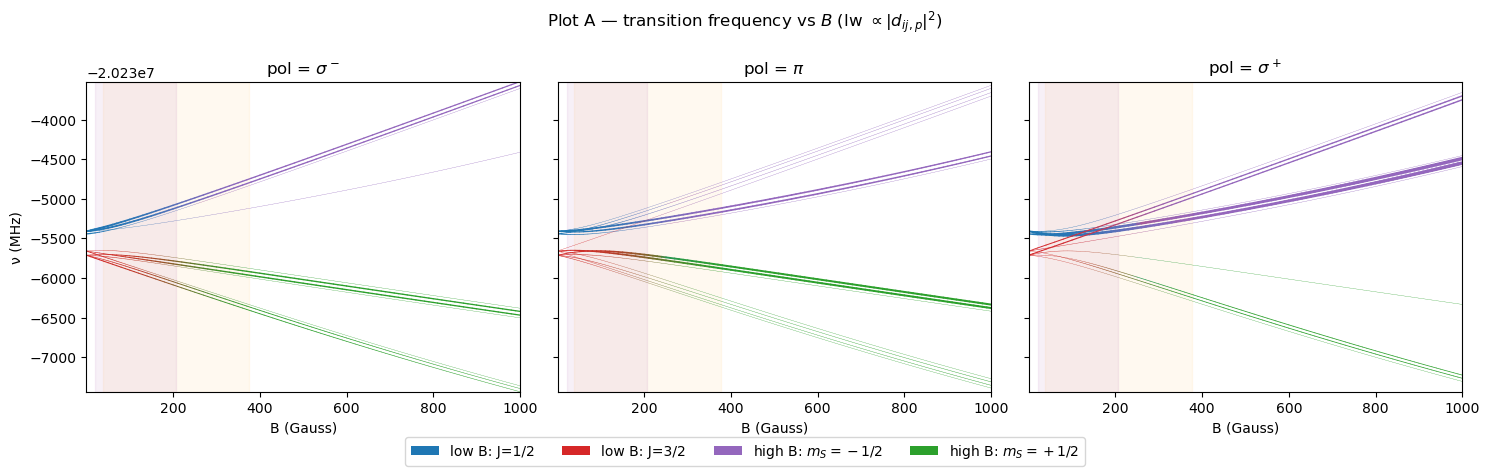

In [9]:
import molecule_parameters as _mp
_X0 = _mp.molecules['RaF']['boson']['X0']
_B_SR_default = (0.3 * _X0['Gamma_SR'] / mu_B, 3.0 * _X0['Gamma_SR'] / mu_B)
_B_HF_default = (0.3 * _X0['bF']       / mu_B, 3.0 * _X0['bF']       / mu_B)

def plot_A_transition_frequencies(TM, g_char, g_pos,
                                  B_SR_PB=_B_SR_default, B_HF_PB=_B_HF_default,
                                  lw_min=0.2, lw_max=2.5,
                                  fig_kwargs=None):
    Bz   = TM['Bz']
    dE   = TM['dE']
    TDM2 = TM['TDM2_BR']        # branching ratios; sum to 1 over (p, g_full) per e
    _vmax = float(TDM2.max()) if TDM2.max() > 0 else 1.0   # visual saturation at brightest BR
    p_lab = TM['p_lab']
    n_B, _, n_e, n_g = TDM2.shape

    # color: J at low B blends to mS at high B as logistic in B around B_SR_PB[1]
    B_PB_mid = 0.5*(B_SR_PB[0] + B_SR_PB[1])
    w_high   = 1 / (1 + np.exp(-(Bz - B_PB_mid)/(0.25*B_PB_mid)))   # 0->low, 1->high
    # discrete colormap for J ∈ {1/2, 3/2}, mS ∈ {-1/2, +1/2}
    J_vals = np.unique(g_char['J'][0, g_pos])
    cmap_low  = {0.5: '#1f77b4', 1.5: '#d62728'}
    cmap_high = {-0.5: '#9467bd', 0.5: '#2ca02c'}

    fig_kwargs = fig_kwargs or dict(figsize=(15, 4.5))
    fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, **fig_kwargs)
    pol_names = [r'$\sigma^-$', r'$\pi$', r'$\sigma^+$']
    for ip, ax in enumerate(axes):
        for je in range(n_e):
            for ig in range(n_g):
                lw = lw_min + (lw_max - lw_min) * np.clip(TDM2[:, ip, je, ig] / _vmax, 0, 1)
                if lw.max() < 1.05*lw_min:
                    continue
                # build segment colors: blend low (J) and high (mS)
                Jdom  = g_char['J'] [:, g_pos[ig]]
                mSdom = g_char['mS'][:, g_pos[ig]]
                # snap to nearest known categories
                colors_low  = np.array([to_rgba(cmap_low.get (round(2*j)/2, '#888'))  for j  in Jdom])
                colors_high = np.array([to_rgba(cmap_high.get(round(2*m)/2, '#888')) for m in mSdom])
                W = w_high[:, None]
                colors = (1-W)*colors_low + W*colors_high

                # plot as colored line segments via LineCollection
                from matplotlib.collections import LineCollection
                pts  = np.column_stack([Bz, dE[:, je, ig]])
                segs = np.stack([pts[:-1], pts[1:]], axis=1)
                seg_col = 0.5*(colors[:-1] + colors[1:])
                seg_lw  = 0.5*(lw   [:-1] + lw   [1:])
                lc = LineCollection(segs, colors=seg_col, linewidths=seg_lw, capstyle='round')
                ax.add_collection(lc)
        ax.axvspan(*B_SR_PB, alpha=0.06, color='orange', label='SR Paschen-Back' if ip==0 else None)
        ax.axvspan(*B_HF_PB, alpha=0.06, color='purple',  label='HF Paschen-Back (est.)' if ip==0 else None)
        ax.set_xlabel('B (Gauss)')
        if ip == 0: ax.set_ylabel('ν (MHz)')
        ax.set_title(f'pol = {pol_names[ip]}')

    ax.set_xlim(Bz.min(), Bz.max())
    ax.set_ylim(np.nanmin(dE), np.nanmax(dE))

    # legend (color encoding)
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=cmap_low [0.5], label='low B: J=1/2'),
               Patch(facecolor=cmap_low [1.5], label='low B: J=3/2'),
               Patch(facecolor=cmap_high[-0.5],label='high B: $m_S=-1/2$'),
               Patch(facecolor=cmap_high[ 0.5],label='high B: $m_S=+1/2$')]
    fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle('Plot A — transition frequency vs $B$ (lw $\\propto |d_{ij,p}|^2$)')
    fig.tight_layout()
    return fig, axes

figA, _ = plot_A_transition_frequencies(TM, g_char_full, g_pos)
plt.show()

### Plot B — slope $d\nu_{ij}/dB$ vs $B$, with Doppler-trackable bands

Cluster `(j,i,p)` transitions that share BOTH `dν/dB` (within `tol`) AND mean
frequency (within `freq_tol_MHz`) over the B-window where both are bright. The
joint criterion is what "Doppler-trackable" actually requires — slope agreement
alone is necessary but not sufficient (two ~zero-offset transitions at very
different frequencies need different lasers, even if their B-tracking is
identical). Zero-slope transitions are flagged as untrackable for any laser.

22 total clusters; 4 with at least 3 members (candidate Doppler-trackable bands)


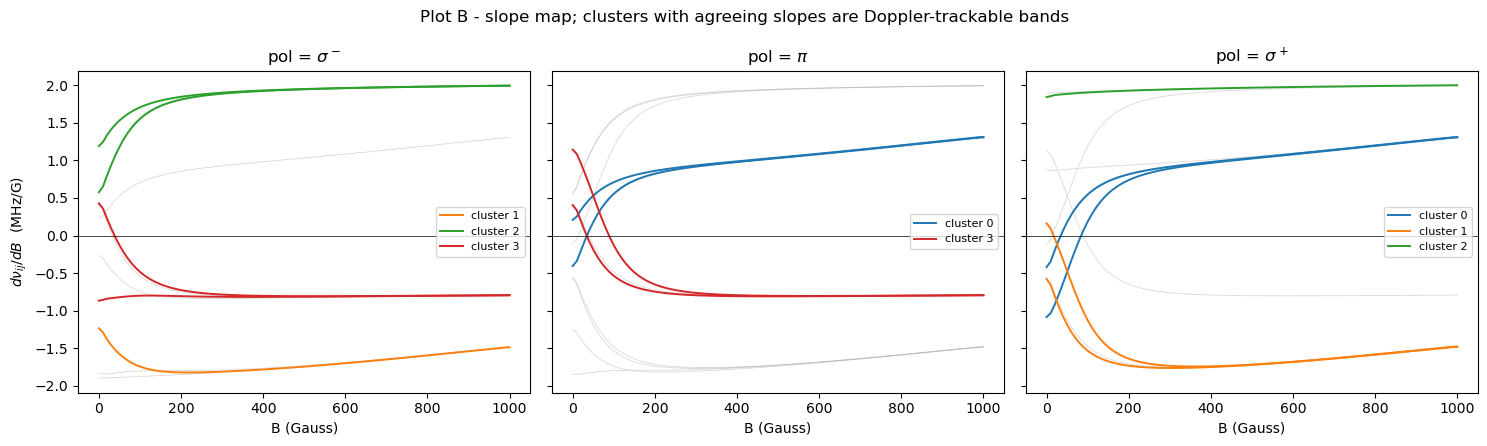

In [10]:
def find_doppler_trackable_bands(TM, tol=0.2, min_TDM2=0.05,
                                   min_overlap=0.4, freq_tol_MHz=200.):
    """Cluster (j,i,p) transitions sharing slope-vs-B AND mean frequency.

    Two transitions cluster only if (a) median relative slope difference is
    within `tol` over at least `min_overlap` of the bright-overlap B-window,
    AND (b) their mean frequency over that window is within `freq_tol_MHz`.
    Set freq_tol_MHz=np.inf to recover the slope-only behavior.
    """
    sl   = TM["slope"]                     # (N_B, n_e, n_g)
    TDM2 = TM["TDM2_BR"]                   # (N_B, 3, n_e, n_g) — branching ratios
    N_B, _, n_e, n_g = TDM2.shape
    bright = (TDM2.max(axis=(0,1)) > min_TDM2)   # (n_e, n_g)
    j_e, j_g = np.where(bright)
    keys = []; curves = []; weights = []
    for je, ig in zip(j_e, j_g):
        for ip in range(3):
            w = TDM2[:, ip, je, ig]
            if w.max() < min_TDM2: continue
            keys.append((int(je), int(ig), int(ip)))
            curves.append(sl[:, je, ig])
            weights.append(w)
    curves  = np.array(curves)
    weights = np.array(weights)

    clusters = []
    assigned = np.zeros(len(curves), dtype=bool)
    for i in range(len(curves)):
        if assigned[i]: continue
        members = [i]; assigned[i] = True
        for j in range(i+1, len(curves)):
            if assigned[j]: continue
            mask = (weights[i] > min_TDM2) & (weights[j] > min_TDM2)
            if mask.sum() < min_overlap * N_B: continue
            denom = np.maximum(np.abs(curves[i][mask]), np.abs(curves[j][mask]))
            denom = np.where(denom < 1e-9, 1e-9, denom)
            rel   = np.abs(curves[i][mask] - curves[j][mask]) / denom
            if np.median(rel) > tol: continue
            # frequency-coincidence test
            je_i, ig_i, _ = keys[i]; je_j, ig_j, _ = keys[j]
            df = np.abs(TM["dE"][mask, je_i, ig_i].mean()
                      - TM["dE"][mask, je_j, ig_j].mean())
            if df > freq_tol_MHz: continue
            members.append(j); assigned[j] = True
        clusters.append([keys[m] for m in members])
    return clusters, keys

def plot_B_slopes(TM, g_char, g_pos, clusters,
                  zero_slope_thresh=0.005, min_TDM2=0.02, fig_kwargs=None):
    Bz   = TM["Bz"]; sl = TM["slope"]; TDM2 = TM["TDM2_BR"]
    N_B, _, n_e, n_g = TDM2.shape
    pol_names = [r"$\sigma^-$", r"$\pi$", r"$\sigma^+$"]
    fig_kwargs = fig_kwargs or dict(figsize=(15, 4.5))
    fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, **fig_kwargs)

    big_clusters = [c for c in clusters if len(c) >= 3]
    cmap = plt.get_cmap("tab10")

    for ip, ax in enumerate(axes):
        # background grey lines for all visible transitions
        for je in range(n_e):
            for ig in range(n_g):
                w = TDM2[:, ip, je, ig]
                if w.max() < min_TDM2: continue
                ax.plot(Bz, sl[:, je, ig], color="0.7", lw=0.6, alpha=0.5)

        # cluster overlays
        for ic, cl in enumerate(big_clusters):
            label_drawn = False
            for (je, ig, ipp) in cl:
                if ipp != ip: continue
                lbl = f"cluster {ic}" if not label_drawn else None
                ax.plot(Bz, sl[:, je, ig], color=cmap(ic % 10), lw=1.4, label=lbl)
                label_drawn = True

        # zero-slope flag
        zs_drawn = False
        for je in range(n_e):
            for ig in range(n_g):
                if TDM2[:, ip, je, ig].max() < min_TDM2: continue
                if np.abs(sl[:, je, ig]).max() < zero_slope_thresh:
                    lbl = "zero-slope (untrackable)" if not zs_drawn else None
                    ax.plot(Bz, sl[:, je, ig], color="red", lw=1.6, alpha=0.7, label=lbl)
                    zs_drawn = True

        ax.axhline(0, color="k", lw=0.5)
        ax.set_xlabel("B (Gauss)"); ax.set_title(f"pol = {pol_names[ip]}")
        if ip == 0: ax.set_ylabel(r"$d\nu_{ij}/dB$  (MHz/G)")
        if big_clusters or zs_drawn:
            ax.legend(fontsize=8, loc="best")

    fig.suptitle("Plot B - slope map; clusters with agreeing slopes are Doppler-trackable bands")
    fig.tight_layout()
    return fig, axes

clusters_all, keys_all = find_doppler_trackable_bands(TM, tol=0.2, min_TDM2=0.05)
n_big = sum(1 for c in clusters_all if len(c) >= 3)
print(f"{len(clusters_all)} total clusters; {n_big} with at least 3 members (candidate Doppler-trackable bands)")
figB, _ = plot_B_slopes(TM, g_char_full, g_pos, clusters_all)
plt.show()

### Plot C — required $B(z)$ per transition

For $v(z) = \sqrt{v_i^2 - 2\eta a_{\max} z}$ with $\eta=0.5$, $v_i=150$ m/s, $v_f=10$ m/s, $L = (v_i^2 - v_f^2)/(2\eta a_{\max})$.

Resonance condition for transition $\nu_{ij}(B) - kv = \nu_L$, with $\nu_L$ fixed at $z=0$ by choosing $B_0$. Linearize: $B(z) = B_0 + k\,(v(z) - v_i) / (d\nu_{ij}/dB)$ — valid where slope changes slowly with $B$.

In [11]:
def slowing_profile(v_i=150., v_f=10., eta=0.5, a_max=None, n_z=400):
    '''v(z) for the user's profile; return (z, v).'''
    if a_max is None:
        # Use a_max consistent with ~1/3 of max scattering force
        # F_max = ħk Γ_angular/2 → a_max = ħk Γ_angular /(2 m). We compute it externally.
        raise ValueError('Provide a_max in m/s^2.')
    L = (v_i**2 - v_f**2) / (2*eta*a_max)
    z = np.linspace(0, L, n_z)
    v = np.sqrt(np.maximum(v_i**2 - 2*eta*a_max*z, v_f**2))
    return z, v, L

def required_Bz(TM, B_0_idx, je, ig, ip, k=k_XA, v_i=150., v_f=10., eta=0.5, a_max=None, n_z=400):
    '''Return (z, v(z), B(z)) for one transition (je, ig, ip), linearized in slope.'''
    Bz = TM['Bz']
    sl = TM['slope'][B_0_idx, je, ig]      # MHz/G (cyclic)
    z, v, L = slowing_profile(v_i, v_f, eta, a_max, n_z)
    # Required cyclic-frequency shift to track v(z) at constant detuning:
    # k v has units rad/s (angular).  ν_Doppler = k v / (2π) (Hz, cyclic) = v/λ.
    dnu_req_Hz = (v - v_i) * k / (2*np.pi)        # Hz (cyclic)
    dnu_req_MHz = dnu_req_Hz * 1e-6
    if abs(sl) < 1e-6:
        return z, v, np.full_like(z, np.nan)
    B0 = Bz[B_0_idx]
    Bz_z = B0 + dnu_req_MHz / sl                  # Gauss
    return z, v, Bz_z

# Compute a_max from F_max = ħk Γ_angular / 2  (radiation-pressure ceiling at full saturation
# of a closed two-level cycle).  Real molecular cycles see η < 1× this due to dark-state
# accumulation, multilevel branching, and detuning losses.
a_max_est = hbar_J * k_XA * Gamma_angular_per_s / (2 * mass_RaF)
print(f'Estimate of max deceleration  a_max ≈ {a_max_est:.3e} m/s^2')

Estimate of max deceleration  a_max ≈ 3.126e+04 m/s^2


B_0 = 420.0 G  (index 42)


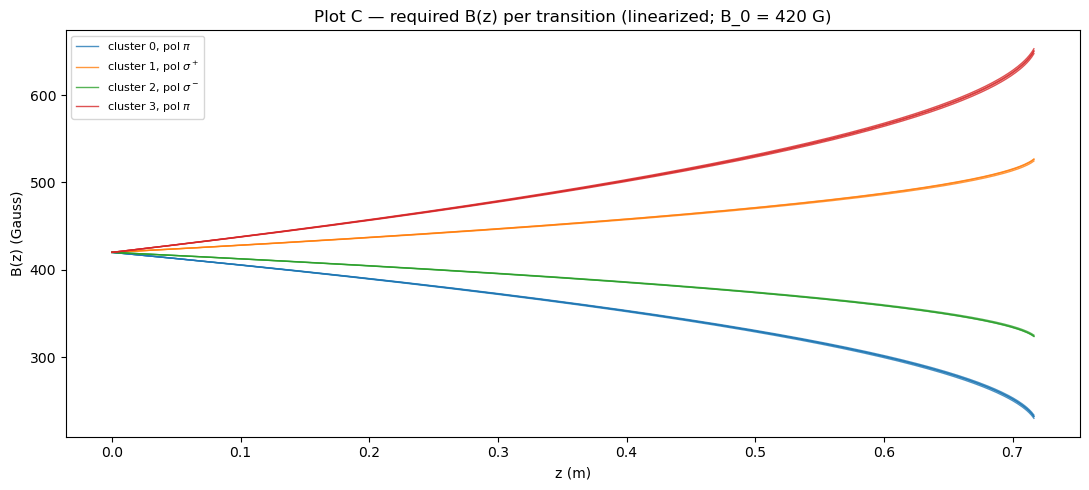

In [12]:
# Plot C: overlay B(z) for the 'best' transitions (those in the largest cluster)
def plot_C_required_Bz(TM, g_char, g_pos, clusters,
                       v_i=150., v_f=10., eta=0.5, a_max=None,
                       B_0=None, min_TDM2=0.05, fig_kwargs=None):
    Bz = TM['Bz']
    if B_0 is None:
        # default to mid-grid (representative slope)
        B_0_idx = len(Bz) // 2
    else:
        B_0_idx = int(np.argmin(np.abs(Bz - B_0)))
    print(f'B_0 = {Bz[B_0_idx]:.1f} G  (index {B_0_idx})')

    fig_kwargs = fig_kwargs or dict(figsize=(11, 5))
    fig, ax = plt.subplots(**fig_kwargs)
    pol_names = [r'$\sigma^-$', r'$\pi$', r'$\sigma^+$']
    cmap = plt.get_cmap('tab10')
    plotted = []
    big_clusters = [c for c in clusters if len(c) >= 3]
    if not big_clusters:
        big_clusters = clusters[:1]  # show at least the largest if no big ones
    for ic, cl in enumerate(big_clusters):
        for (je, ig, ip) in cl:
            if TM['TDM2_BR'][B_0_idx, ip, je, ig] < min_TDM2: continue
            z, v, Bz_z = required_Bz(TM, B_0_idx, je, ig, ip,
                                     v_i=v_i, v_f=v_f, eta=eta, a_max=a_max)
            ax.plot(z, Bz_z, color=cmap(ic % 10), alpha=0.8, lw=1.0,
                    label=f'cluster {ic}, pol {pol_names[ip]}' if (je,ig,ip)==cl[0] else None)
            plotted.append((ic, je, ig, ip))
    ax.set_xlabel('z (m)'); ax.set_ylabel('B(z) (Gauss)')
    ax.set_title(f'Plot C — required B(z) per transition (linearized; B_0 = {Bz[B_0_idx]:.0f} G)')
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig, ax, plotted

figC, axC, _ = plot_C_required_Bz(TM, g_char_full, g_pos, clusters_all,
                                  a_max=a_max_est, B_0=420.)
plt.show()

### Plot D — branching-ratio map

For each excited level $j$ and **photon** polarization $p$, the fractional spontaneous-emission rate to each ground sublevel: $\mathrm{BR}_{ji,p} = |\langle g_i|T^p|e_j\rangle|^2 / \sum_{p'} \sum_{i'\in\rm all\,grounds} |\langle g_{i'}|T^{p'}|e_j\rangle|^2$. We split into:

* "diagonal" — $\sum_{p}\mathrm{BR}_{ji,p}$ summed over the *selected* (slowing) ground-state subspace,
* "leakage" — $1 - \mathrm{diagonal}$, ie decays to states outside the subspace (need repumps or remixing).

In [13]:
def compute_branching(TM_full, e_pos, g_pos):
    '''Return BR_per_p (N_B, 3, n_e_sub, n_g_sub), BR_total (N_B, n_e_sub, n_g_sub),
    leakage (N_B, n_e_sub). Uses TM_full["TDM2_BR_full"] which already sums to 1
    over (p, g_full) per excited state.'''
    e_idx_sub = TM_full['e_idx'][e_pos]
    g_idx_sub = TM_full['g_idx'][g_pos]
    BR_sub_per_p = TM_full['TDM2_BR_full'][:, :, e_idx_sub[:, None], g_idx_sub[None, :]]
    BR_sub_total = BR_sub_per_p.sum(axis=1)
    leakage      = 1.0 - BR_sub_total.sum(axis=2)
    return BR_sub_per_p, BR_sub_total, leakage

BR_per_p, BR_total, leakage = compute_branching(TM_full, e_pos, g_pos)
print('BR_per_p shape:', BR_per_p.shape, 'leakage shape:', leakage.shape)
print('mean leakage (N=1 cycle, all B):', leakage.mean())

BR_per_p shape: (101, 3, 4, 12) leakage shape: (101, 4)
mean leakage (N=1 cycle, all B): 7.969422701517212e-18


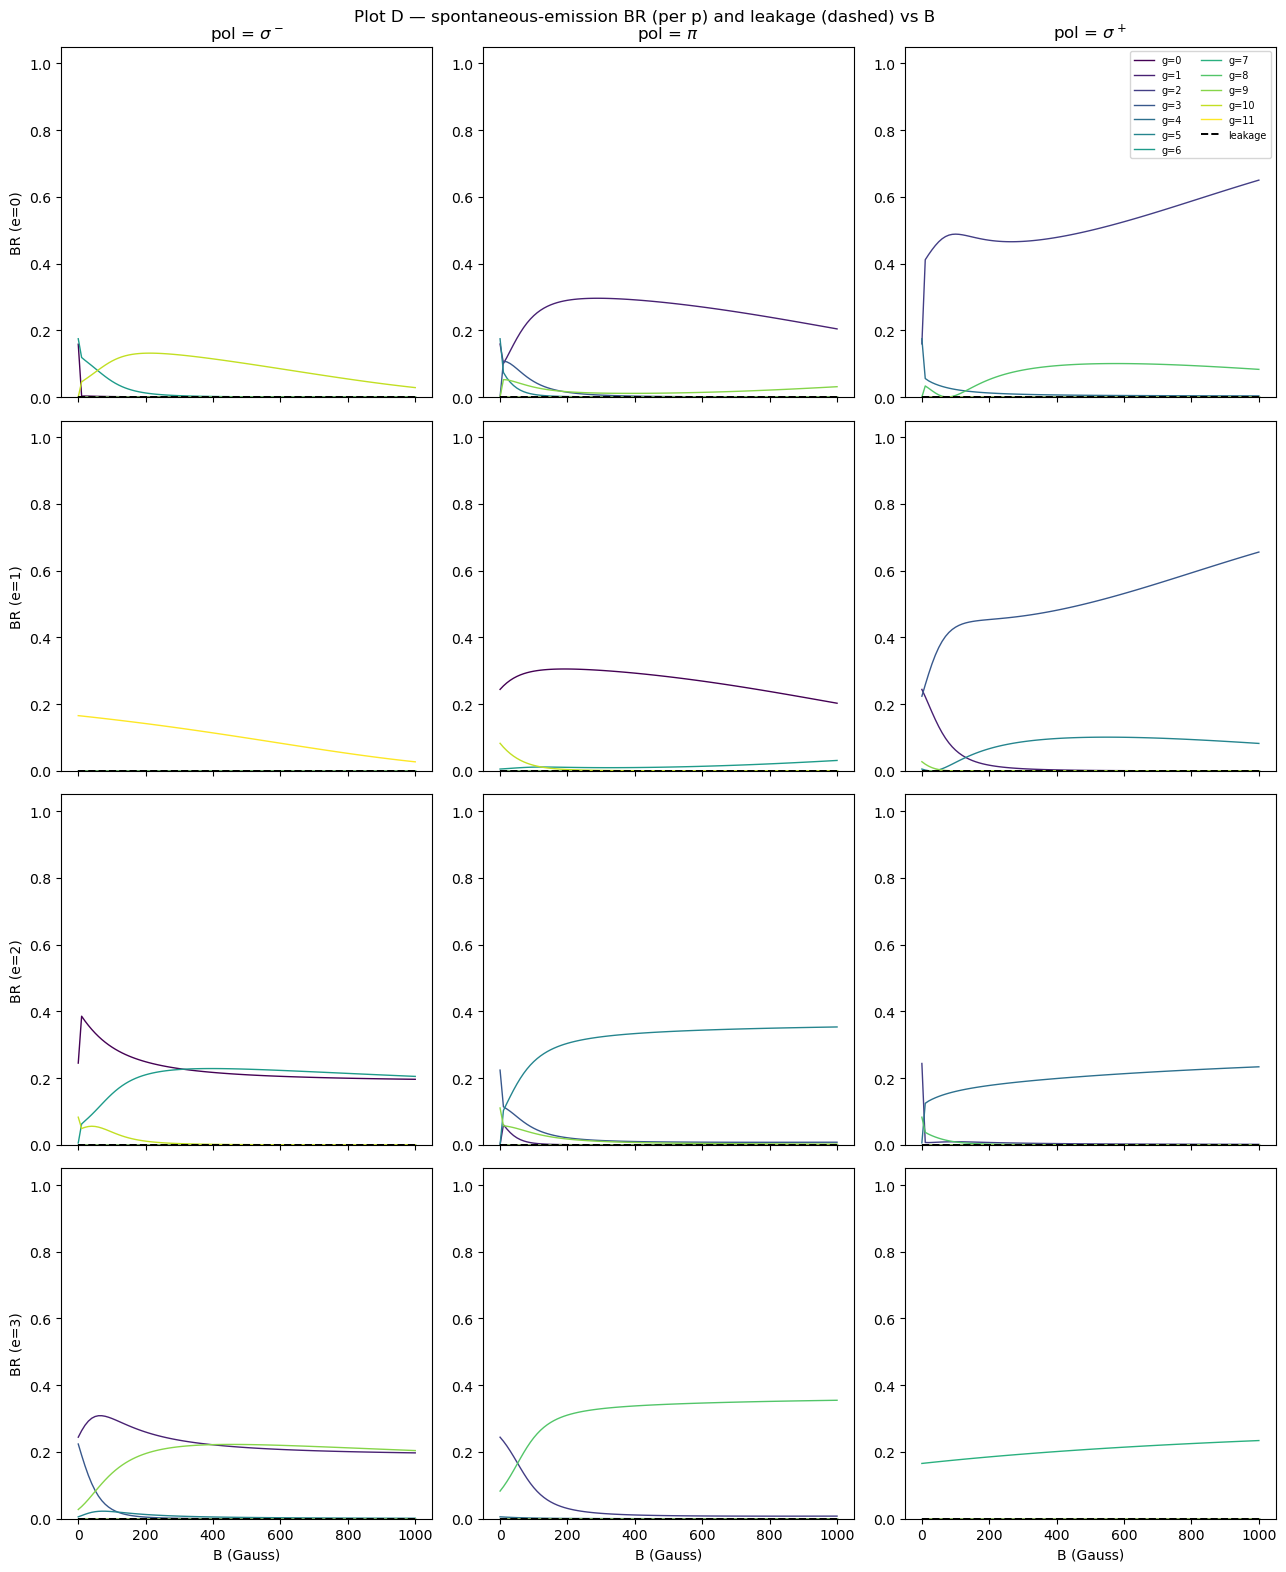

In [14]:
def plot_D_branching(TM, BR_per_p, BR_total, leakage, fig_kwargs=None):
    Bz = TM['Bz']
    n_B, _, n_e, n_g = BR_per_p.shape
    fig_kwargs = fig_kwargs or dict(figsize=(13, 4*n_e))
    fig, axes = plt.subplots(n_e, 3, sharex=True, **fig_kwargs)
    if n_e == 1: axes = axes.reshape(1, 3)
    pol_names = [r'$\sigma^-$', r'$\pi$', r'$\sigma^+$']
    cmap = plt.get_cmap('viridis', n_g)
    for je in range(n_e):
        for ip in range(3):
            ax = axes[je, ip]
            for ig in range(n_g):
                ax.plot(Bz, BR_per_p[:, ip, je, ig], color=cmap(ig), lw=1.0,
                        label=f'g={ig}')
            ax.plot(Bz, leakage[:, je], color='k', lw=1.4, ls='--', label='leakage')
            ax.set_ylim(0, 1.05)
            if je == 0: ax.set_title(f'pol = {pol_names[ip]}')
            if ip == 0: ax.set_ylabel(f'BR (e={je})')
            if je == n_e-1: ax.set_xlabel('B (Gauss)')
            if (je, ip) == (0, 2): ax.legend(fontsize=7, ncol=2, loc='upper right')
    fig.suptitle('Plot D — spontaneous-emission BR (per p) and leakage (dashed) vs B')
    fig.tight_layout()
    return fig, axes

figD, _ = plot_D_branching(TM, BR_per_p, BR_total, leakage)
plt.show()

### Plot E — dark-state count vs $B$ per polarization

A ground sublevel $i$ is "dark" to polarization $p$ at field $B$ if $\sum_j |d_{ji,p}(B)|^2_{\rm norm} < 0.01$.

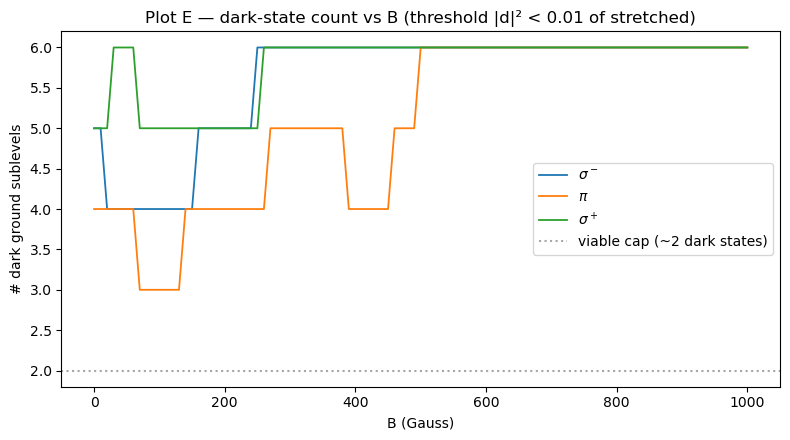

In [15]:
def dark_state_count(TM, threshold=0.01):
    '''Dark = sum_e BR(e -> g, p) below threshold for ground sublevel g and pol p.
    Equivalently: total decay flux through (p, g) summed over all excited states.
    For a closed cycle with ~equal Gamma_e, this is also proportional to absorption
    strength from g to any e at polarization p (detailed balance).'''
    TDM2 = TM['TDM2_BR']                        # (N_B, 3, n_e, n_g) — branching ratios
    sum_over_e = TDM2.sum(axis=2)               # (N_B, 3, n_g)
    is_dark    = sum_over_e < threshold
    counts     = is_dark.sum(axis=2)            # (N_B, 3)
    return counts, is_dark

def plot_E_dark_states(TM, threshold=0.01, fig_kwargs=None):
    counts, _ = dark_state_count(TM, threshold)
    Bz = TM['Bz']
    fig_kwargs = fig_kwargs or dict(figsize=(8, 4.5))
    fig, ax = plt.subplots(**fig_kwargs)
    pol_names = [r'$\sigma^-$', r'$\pi$', r'$\sigma^+$']
    for ip in range(3):
        ax.plot(Bz, counts[:, ip], lw=1.3, label=pol_names[ip])
    ax.axhline(2, color='gray', ls=':', alpha=0.7, label='viable cap (~2 dark states)')
    ax.set_xlabel('B (Gauss)'); ax.set_ylabel('# dark ground sublevels')
    ax.set_title(f'Plot E — dark-state count vs B (threshold |d|² < {threshold} of stretched)')
    ax.legend()
    fig.tight_layout()
    return fig, ax

figE, _ = plot_E_dark_states(TM, threshold=0.01)
plt.show()

## Step 4 — rate-equation force calculation

Following Tarbutt (2018) and Yan & Liang (2019). Steady-state rate equations for $n_g + n_e$ levels:

$$ R_{lu,p}(B,v) = \frac{\Gamma}{2}\,\frac{s_p\, b_{lu,p}(B)}{1 + 4\Delta_{lu,p}^2/\Gamma^2} $$

with $b_{lu,p}(B) = |d_{lu,p}(B)|^2_{\rm norm}$, $s_p$ = on-resonance saturation per polarization,
$\Delta_{lu,p}(B,v) = (\omega_L + \delta_p) - \omega_{lu}(B) + kv$
(counter-propagating beam at $-\hat z$: molecule moving in $+\hat z$ at velocity $v$ sees blue shift $+kv$).

**No saturation in the denominator.** We follow Tarbutt 2014 NJP Eq 2: $R$ is linear in $s_p$, and saturation is enforced by the population-balance equation below (the rate matrix $M$ caps the cycle through finite excited-state lifetime). The closed two-level OBE form $1+s+4\Delta^2/\Gamma^2$ in Steck/thesis is the *steady-state population*, not to be substituted into a rate-equation framework.

**Cyclic vs angular.** $\Delta$ and $\Gamma$ in the Lorentzian must be in matched units; the $(2\Delta/\Gamma)^2$ ratio cancels them. Code uses cyclic $\Delta$ (MHz) and cyclic $\Gamma_{\rm FWHM}$ (MHz). Spontaneous-decay terms in $M$ use $\Gamma_{\rm angular}$ (1/s).

Steady-state populations satisfy $M \mathbf{N} = 0$ with $\sum N = 1$. The total force is

$$ F = \sum_{l,u,p} \hbar k_p \, R_{lu,p}(B,v)\,(N_l - N_u). $$

For the slowing (counter-propagating beam at $-\hat z$) we take $k_p \rightarrow -k$ for all polarizations (single beam direction, polarization is the spin angular momentum carried).

We restrict to the closed cycle: $X^2\Sigma\,N{=}1 \to A^2\Pi_{1/2}\,J'{=}1/2,\,+\text{parity}$. Leakage to other ground states is *separately* logged from Plot D — assumed zero in the rate equations (perfect repumping or chosen subspace closure).

**Caveat: laser auto-retunes per query.** `steady_state_rate_eq` re-anchors `nu_L_ref_MHz` at the queried `B` so the reference transition is on resonance. F(v, B) plots therefore represent the optimum-tuned-laser envelope at each B, NOT a fixed-frequency laser sweep.


In [16]:
def _polarization_to_intensity_fractions(polarization):
    """Decompose a lab polarization spec into intensity fractions in spherical components.
    Returns array [|w_-1|^2, |w_0|^2, |w_+1|^2] summing to 1.
    Accepts: 'sigma+', 'sigma-', 'pi'/'z', 'x', 'y', or dict {p: frac} where p in {-1,0,+1}.
    For coherent linear (x, y) the intensity is split 50/50 between p=-1 and p=+1.
    For dict input, values are intensity fractions; the function normalizes if they don't sum to 1.
    """
    if isinstance(polarization, dict):
        out = np.zeros(3)
        for k, v in polarization.items():
            kk = int(k) if isinstance(k, str) else int(k)
            out[{-1:0, 0:1, +1:2}[kk]] = float(v)
        s = out.sum()
        return out / s if s > 0 else out
    s = polarization.lower()
    table = {
        'sigma+':   [0.0, 0.0, 1.0],
        'sigma_plus': [0.0, 0.0, 1.0],
        's+':       [0.0, 0.0, 1.0],
        'sigma-':   [1.0, 0.0, 0.0],
        'sigma_minus': [1.0, 0.0, 0.0],
        's-':       [1.0, 0.0, 0.0],
        'pi':       [0.0, 1.0, 0.0],
        'z':        [0.0, 1.0, 0.0],
        'x':        [0.5, 0.0, 0.5],
        'y':        [0.5, 0.0, 0.5],
    }
    if s not in table:
        raise ValueError(f"Unknown polarization {polarization!r}")
    return np.array(table[s])


def steady_state_rate_eq(TM, Bz_query, v, sidebands,
                          ref_transition=None,
                          Gamma_FWHM_MHz=Gamma_FWHM_MHz, remix=1e-3,
                          verbose_leakage=True, leakage_thresh=0.01):
    """Solve dN/dt = 0 for one (B, v) and return populations + force.

    Frequency convention: detunings are stored as cyclic MHz (Hz / 1e6); the rate
    Lorentzian uses (2*Delta/Gamma_FWHM)**2 with both Delta and Gamma_FWHM cyclic
    so the ratio is dimensionless.  Spontaneous-decay terms in the rate matrix M
    use Gamma_angular = 2*pi*Gamma_FWHM_MHz*1e6 in 1/s.

    Multi-sideband laser: each entry of `sidebands` is a dict
        {'detuning_MHz': float,   # offset from reference transition's resonance at this B (cyclic MHz)
         's':            float,   # I_n / I_s, with I_s = pi*h*c*Gamma/(3*lambda^3)
                                  # (thesis Eq 3.21 isotropically averaged 2-level I_sat;
                                  #  for RaF X-A at Gamma_FWHM=4.6 MHz, lambda=753 nm: I_s ~ 1.41 mW/cm^2)
         'polarization': 'sigma+'|'sigma-'|'pi'|'x'|'y'|{p: intensity_fraction}}

    Per-channel rate sums over sidebands; each sideband n contributes
        R_{lu,p}^{(n)} = (Gamma_angular / 2) * f_n[p] * s_n * b_{lu,p}
                          / (1 + (2 * (nu_L_ref + delta_n - nu_lu + Doppler) / Gamma_FWHM)**2)
    where b_{lu,p} = TDM2_BR is the per-channel branching ratio (sums to 1 over (p,g) per e),
    f_n[p] is the intensity fraction in spherical component p for sideband n,
    Doppler = +k*v/(2pi) for counter-propagating beam at -z (molecule sees blue shift).

    Saturation in denominator: NONE (Tarbutt 2014 Eq 2 convention). Population balance
    in the rate matrix below caps the cycle at high intensity.
    """
    Bz = TM['Bz']
    iB = int(np.argmin(np.abs(Bz - Bz_query)))
    TDM2 = TM['TDM2_BR']          # (N_B, 3, n_e, n_g) — branching ratios
    dE   = TM['dE']               # cyclic MHz   (e - g)
    n_B, _, n_e, n_g = TDM2.shape

    # Per-sideband saturation vectors and aggregate effective saturation per p
    sb_specs = []
    s_vec_eff_total = np.full(3, remix, dtype=float)   # for dark-state mixing only
    for sb in sidebands:
        frac = _polarization_to_intensity_fractions(sb['polarization'])
        s_n  = float(sb['s'])
        sb_specs.append((float(sb['detuning_MHz']), s_n, frac))

    # Reference transition (defines nu_L_ref(B)): brightest channel (BR-wise) at B=0,
    # summed over polarization (independent of sideband config so multiple sidebands share
    # a common nu_L_ref).  Override via ref_transition.
    if ref_transition is None:
        je0, ig0 = np.unravel_index(np.argmax(TDM2[0].sum(axis=0)), (n_e, n_g))
    else:
        je0, ig0 = ref_transition
    nu_L_ref_MHz = dE[iB, je0, ig0]                            # cyclic MHz; laser on-res at this B

    nu_lu       = dE[iB]                                       # (n_e, n_g) cyclic MHz
    Doppler_MHz = k_XA * v / (2*np.pi) * 1e-6                  # cyclic MHz; +k v/(2pi) for counter-prop beam at -z

    Gamma_angular_local = 2*np.pi * Gamma_FWHM_MHz * 1e6        # rad/s = 1/s (for spontaneous decay)
    prefac = Gamma_angular_local / 2.0                          # Gamma_angular/2 in 1/s
    R_p_eff   = np.zeros((3, n_e, n_g))                         # rate per pol (1/s)
    R_p_force = np.zeros((3, n_e, n_g))                         # force-contributing rate

    # Sum over sidebands
    for delta_n, s_n, frac in sb_specs:
        Delta_n_MHz = nu_L_ref_MHz + delta_n - nu_lu + Doppler_MHz   # (n_e, n_g) cyclic MHz
        denom_n = 1.0 + (2.0 * Delta_n_MHz / Gamma_FWHM_MHz)**2       # dimensionless: Delta and Gamma both cyclic
        for ip in range(3):
            b = TDM2[iB, ip]
            sat_force = s_n * frac[ip] * b
            R_p_force[ip] += prefac * sat_force / denom_n             # 1/s

    # add remix as a pseudo-on-resonance saturation (lifts dark states) — does NOT contribute to force
    R_p_eff[:] = R_p_force[:]
    for ip in range(3):
        R_p_eff[ip] += prefac * (remix * TDM2[iB, ip])         # remix already = saturation; treats as on-res
    R = R_p_eff.sum(axis=0)                                    # (n_e, n_g)

    # Spontaneous-emission BR within subset (closed-cycle assumption).
    weights_e2g = TDM2[iB].sum(axis=0)                          # (n_e, n_g) — subset, normalized
    Z_subset_norm = weights_e2g.sum(axis=1)                     # (n_e,)
    BR_e2g = weights_e2g / np.where(Z_subset_norm[:, None] > 0, Z_subset_norm[:, None], 1.0)
    # Leakage diagnostic — raw |TDM_full|^2 for both num and denom (units consistent).
    e_idx_full = TM['e_idx']; g_idx_sub = TM['g_idx']
    weights_full_raw = (np.abs(TM['TDM_full'][iB])**2).sum(axis=0)
    Z_full_raw   = weights_full_raw[e_idx_full, :].sum(axis=1)
    Z_subset_raw = weights_full_raw[e_idx_full[:, None], g_idx_sub[None, :]].sum(axis=1)
    leakage_at_B = 1.0 - Z_subset_raw / np.where(Z_full_raw > 0, Z_full_raw, 1.0)
    if verbose_leakage and leakage_at_B.max() > leakage_thresh:
        print(f"⚠ closed-cycle assumption: subset leakage = "
              f"{100*leakage_at_B.max():.2f}% at B = {Bz[iB]:.1f} G")
    Gamma_total_s = Gamma_angular_local                         # 1/s

    # Build linear rate matrix M (N_g + N_e × same)
    nT = n_g + n_e
    M = np.zeros((nT, nT))
    for l in range(n_g):
        for u in range(n_e):
            r  = R[u, l]
            br = BR_e2g[u, l] * Gamma_total_s
            M[l, l]         -= r
            M[l, n_g + u]   += r + br
    for u in range(n_e):
        for l in range(n_g):
            r = R[u, l]
            M[n_g + u, l]         += r
            M[n_g + u, n_g + u]   -= r
        M[n_g + u, n_g + u] -= Gamma_total_s

    Mr = np.vstack([M, np.ones((1, nT))])
    rhs = np.concatenate([np.zeros(nT), [1.0]])
    N, *_ = np.linalg.lstsq(Mr, rhs, rcond=None)
    N = np.clip(N, 0, None)
    N = N / N.sum()

    Nl = N[:n_g]; Nu = N[n_g:]
    pop_diff = Nl[None, :] - Nu[:, None]                        # (n_e, n_g)
    scattering_rate = (R_p_force * pop_diff[None, :, :]).sum()  # 1/s
    F = -hbar_J * k_XA * scattering_rate                        # N

    return {
        'N': N, 'Nl': Nl, 'Nu': Nu,
        'R_per_pol': R_p_force, 'BR_e2g': BR_e2g,
        'F': F, 'scattering_rate': scattering_rate,
        'Bz_used': Bz[iB], 'nu_L_ref_MHz': nu_L_ref_MHz,
        'iB': iB, 'ref': (je0, ig0),
        'leakage': leakage_at_B,
    }

# Smoke test — single-sideband on sigma+, s=2, on resonance with strongest line at B=200 G
_sb_test = [{'detuning_MHz': 0.0, 's': 2.0, 'polarization': 'sigma+'}]
res = steady_state_rate_eq(TM, 200., 0., sidebands=_sb_test, remix=1e-3)
print(f"  R_total = {res['scattering_rate']:.3e} /s,   F = {res['F']:.3e} N")
print(f"  ground populations: {np.round(res['Nl'], 3)}")
print(f"  excited populations: {np.round(res['Nu'], 3)}, sum_N = {res['N'].sum():.6f}")

  R_total = 2.200e+02 /s,   F = -1.936e-25 N
  ground populations: [0.092 0.083 0.076 0.082 0.072 0.091 0.091 0.071 0.083 0.084 0.084 0.093]
  excited populations: [0. 0. 0. 0.], sum_N = 1.000000


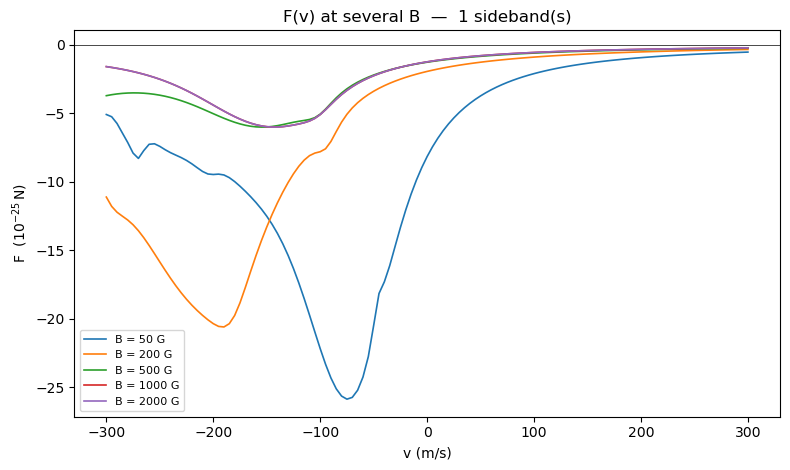

In [17]:
# Plot F(v) at several B for a single-sideband configuration.  Pass a list of
# sideband dicts to vary intensity, detuning, polarization; this caller uses one.
def plot_force_vs_v(TM, B_list_G, sidebands, v_min=-300, v_max=300, n_v=121,
                    label_fn=None):
    v_arr = np.linspace(v_min, v_max, n_v)
    fig, ax = plt.subplots(figsize=(8, 4.8))
    for B in B_list_G:
        F_arr = np.array([steady_state_rate_eq(
            TM, B, v, sidebands=sidebands, verbose_leakage=False)['F'] for v in v_arr])
        ax.plot(v_arr, F_arr*1e25, lw=1.2, label=f'B = {B:.0f} G')
    ax.set_xlabel('v (m/s)'); ax.set_ylabel(r'F  $(10^{-25}\,$N)')
    ax.axhline(0, color='k', lw=0.5)
    sb_label = label_fn(sidebands) if label_fn else f'{len(sidebands)} sideband(s)'
    ax.set_title(f'F(v) at several B  —  {sb_label}')
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig, ax, v_arr

_sb = [{'detuning_MHz': 0.0, 's': 2.0, 'polarization': 'sigma+'}]
figF1, _, v_arr = plot_force_vs_v(TM, [50, 200, 500, 1000, 2000], _sb)
plt.show()

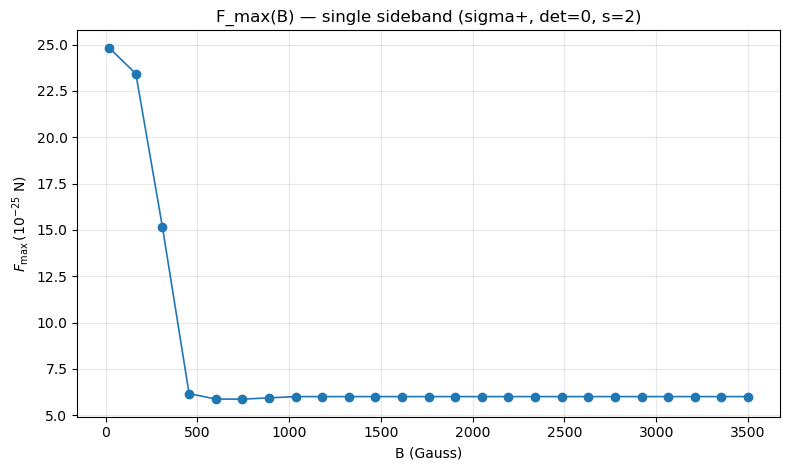

peak F_max @ B (G): 20.0 ,  v_at_max: -36.66666666666663  m/s


In [18]:
# F_max(B): peak |F| over v at each B for a given sideband configuration.
def F_max_vs_B(TM, B_list_G, sidebands, v_min=-300, v_max=300, n_v=181):
    v_arr = np.linspace(v_min, v_max, n_v)
    F_max = []; v_at_max = []
    for B in B_list_G:
        F_arr = np.array([steady_state_rate_eq(
            TM, B, v, sidebands=sidebands, verbose_leakage=False)['F'] for v in v_arr])
        idx = int(np.argmax(np.abs(F_arr)))
        F_max.append(np.abs(F_arr[idx]))
        v_at_max.append(v_arr[idx])
    return np.array(B_list_G), np.array(F_max), np.array(v_at_max)

_sb = [{'detuning_MHz': 0.0, 's': 2.0, 'polarization': 'sigma+'}]
B_scan = np.linspace(20, 3500, 25)
B_arr, Fm, v_at = F_max_vs_B(TM, B_scan, _sb)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(B_arr, Fm*1e25, '-o', lw=1.2)
ax.set_xlabel('B (Gauss)'); ax.set_ylabel(r'$F_\mathrm{max}\,(10^{-25}$ N)')
ax.set_title('F_max(B) — single sideband (sigma+, det=0, s=2)')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
print('peak F_max @ B (G):', B_arr[np.argmax(Fm)],
      ',  v_at_max:', v_at[np.argmax(Fm)], ' m/s')

## Step 5 — Rotational leakage to X(N=3, parity=−) vs $B$

At zero field, A(J=½, parity=+) is parity-closed to X(N=1, parity=−): the E1
selection rule (parity flip) plus X²Σ⁺ parity = $(-1)^N$ allow only odd-$N$ X
decay channels, and the rotational matrix element constrains $\Delta N = \pm 1$
from the J=½ excited state — so X(N=1) is the only allowed channel.

At higher $B$, Zeeman mixing of A(J=½, +) with A(J=3/2, +) lets the originally-J=½
excited eigenstate spontaneously decay through the J=3/2 angular-momentum
character, opening up X(N=3, parity=−) decays. After enough scatters, this is
an unaddressed loss channel for the cycling cycle.

This cell builds a separate ground basis $g_{\rm ext}$ with `N_list=[1, 3]`
(unchanged X N=1 hyperfine + N=3) and computes the per-excited-state branching
ratio to X(N=3) as a function of $B$. The y-axis is log-scaled because the
leakage is small at low B.

g_ext: total=40, N=1 sublevels=12, N=3 sublevels=28
closure check (BR_to_N1 + BR_to_N3, should ~= 1 for non-trivially coupled e): min=1.000000, max=1.000000


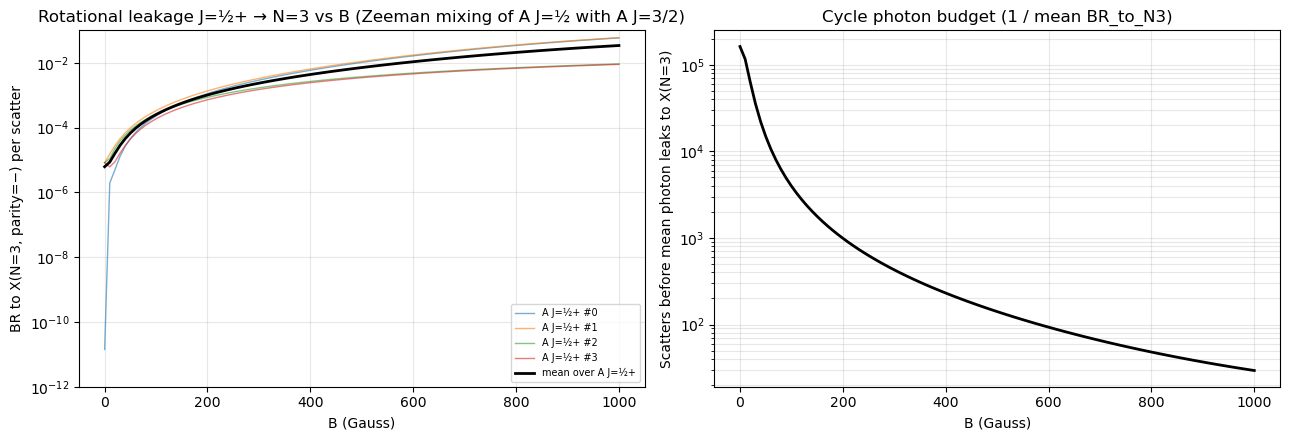


Leakage to X(N=3) at representative B fields (mean over A J=½+ sublevels):
  B =     0.0 G:  mean BR_to_N3 = 6.167e-06  (1.621e+05 scatters before leak)
  B =    50.0 G:  mean BR_to_N3 = 6.727e-05  (1.486e+04 scatters before leak)
  B =   100.0 G:  mean BR_to_N3 = 2.519e-04  (3.970e+03 scatters before leak)
  B =   200.0 G:  mean BR_to_N3 = 1.010e-03  (9.905e+02 scatters before leak)
  B =   500.0 G:  mean BR_to_N3 = 7.096e-03  (1.409e+02 scatters before leak)
  B =  1000.0 G:  mean BR_to_N3 = 3.399e-02  (2.942e+01 scatters before leak)


In [19]:
# Extended ground basis: X N=1 (cycling) + N=3 (leakage target).
g_ext = MoleculeLevels.initialize_state(
    molecule_name='RaF', elec_state='X', vib_state=0,
    N_list=[1, 3], fermion_or_boson='boson',
    M_sublevels='all', I_nuclei=[0, 1/2], isotope=226,
    round=8, P_values=[1/2],
)
g_ext.eigensystem(0, 1e-3)
g_ext.ZeemanMap(Bz, plot=False)

# Build full transition map e -> g_ext for the J=1/2 +parity excited subset.
TM_ext = build_transition_map(g_ext, e,
                              ground_query={'N': [1, 3]},
                              excited_query={'J': 0.5},
                              parity_e='+')

# Per-e BR over (p, g_full); then split into N=1 vs N=3 buckets.
TDM2_full_raw_ext = np.abs(TM_ext['TDM_full'])**2                     # (N_B, 3, n_e_full, n_g_full)
per_e_total_ext   = TDM2_full_raw_ext.sum(axis=(1, 3))                # (N_B, n_e_full)
TDM2_BR_full_ext  = TDM2_full_raw_ext / np.where(per_e_total_ext[:, None, :, None] > 0,
                                                  per_e_total_ext[:, None, :, None], 1.0)

# Identify g_ext indices belonging to N=1 vs N=3.
g_N1_idx = g_ext.select_q({'N': [1]})
g_N3_idx = g_ext.select_q({'N': [3]})
print(f'g_ext: total={g_ext.size}, N=1 sublevels={len(g_N1_idx)}, N=3 sublevels={len(g_N3_idx)}')

# Slice to the J=1/2 +parity excited states (rows of TM_ext['e_idx']).
BR_full_J05 = TDM2_BR_full_ext[:, :, TM_ext['e_idx'], :]              # (N_B, 3, n_e_J05, n_g_full)
BR_to_N1 = BR_full_J05[:, :, :, g_N1_idx].sum(axis=(1, 3))            # (N_B, n_e_J05)
BR_to_N3 = BR_full_J05[:, :, :, g_N3_idx].sum(axis=(1, 3))            # (N_B, n_e_J05)
total_BR = BR_to_N1 + BR_to_N3
print(f'closure check (BR_to_N1 + BR_to_N3, should ~= 1 for non-trivially coupled e): '
      f'min={total_BR.max(axis=1).min():.6f}, max={total_BR.max():.6f}')

# Plot leakage to N=3 vs B per excited sublevel + mean across the manifold.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ej in range(BR_to_N3.shape[1]):
    axes[0].plot(g_ext.Bz, BR_to_N3[:, ej], lw=1.0, alpha=0.6, label=f'A J=½+ #{ej}')
axes[0].plot(g_ext.Bz, BR_to_N3.mean(axis=1), 'k-', lw=2.0, label='mean over A J=½+')
axes[0].set_xlabel('B (Gauss)')
axes[0].set_ylabel('BR to X(N=3, parity=−) per scatter')
axes[0].set_yscale('log')
axes[0].set_ylim(1e-12, 1e-1)
axes[0].set_title('Rotational leakage J=½+ → N=3 vs B (Zeeman mixing of A J=½ with A J=3/2)')
axes[0].legend(fontsize=7, loc='lower right')
axes[0].grid(alpha=0.3, which='both')

# Right panel: scatters before loss = 1 / mean_leakage(B)
axes[1].plot(g_ext.Bz, 1.0 / np.where(BR_to_N3.mean(axis=1) > 0, BR_to_N3.mean(axis=1), 1.0), 'k-', lw=2)
axes[1].set_xlabel('B (Gauss)')
axes[1].set_ylabel('Scatters before mean photon leaks to X(N=3)')
axes[1].set_yscale('log')
axes[1].set_title('Cycle photon budget (1 / mean BR_to_N3)')
axes[1].grid(alpha=0.3, which='both')

fig.tight_layout()
plt.show()

# Numerical summary at a few key fields
print('\nLeakage to X(N=3) at representative B fields (mean over A J=½+ sublevels):')
for B_test in [1, 50, 100, 200, 500, 1000]:
    iB = int(np.argmin(np.abs(g_ext.Bz - B_test)))
    L = BR_to_N3[iB].mean()
    nscat = (1.0/L) if L > 0 else float('inf')
    print(f'  B = {g_ext.Bz[iB]:7.1f} G:  mean BR_to_N3 = {L:.3e}  ({nscat:.3e} scatters before leak)')

## Step 6 — Trajectory simulation through the Zeeman slower

Integrate Newton's law $m\,\dot v = F(v(t), B(z(t)))$ with $\dot z = v$ for a molecule entering the slower at axial velocity $v_0$.  The force surface $F(v, B)$ comes from `steady_state_rate_eq` in the adiabatic-population approximation (cycle equilibration $\sim 35$ ns vs slowing dynamics $\sim 10$ ms; six-orders-separated, fully justified — see Liang & Yan 2019 §III).

**Sweep dimensions** (RaF, $^{226}$Ra$^{19}$F, X²Σ → A²Π½ at 753 nm):
- $B_{\rm design} \in \{150, 250, 500\}$ G — three field-design points (laser tuned on-resonance with brightest cycling transition at this $B$ and at $v_{\rm design} = 80$ m/s)
- $L \in \{1.25, 1.75, 2.25, 2.75\}$ m — slower length sweep, following Liang & Yan 2019 methodology (no analytic formula — they sweep L empirically and pick a "suitable compromise"; Fig 3b of their paper)
- $s \in \{10, 100\}$ — saturation per beam
- $v_0 \in [40, 120]$ m/s in 5 m/s steps — initial-velocity scan
- Stop integration at $v < 5$ m/s OR $z > L$ OR $t > 100$ ms OR $v < 0$ (over-slowing turnaround)

**B(z) construction.** Two methods compared in panel 1 below:
- **Nonlinear**: invert the full $\nu_{\rm eg}(B)$ curve so the chosen reference transition stays Doppler-tuned to a fixed-frequency laser as $v$ drops along the slower.
- **Linearized** (cell 19's `required_Bz`): use the local slope $d\nu_{\rm eg}/dB$ at $B_{\rm design}$.  Accurate near the design point, drifts at the extremes.

**Single laser, no sidebands, σ⁺.**  Adding sidebands later is a one-line change in the `precompute_F_grid` call (sidebands list is forwarded to `steady_state_rate_eq`).

**Force precompute.**  $F(v, B)$ is precomputed once on a $(v, B)$ grid for each $(B_{\rm design}, s)$ combination ($N_v \times N_B$ rate-equation solves; ~minutes total).  Then bilinearly interpolated inside the ODE integrator.  Each precomputed $F$-surface is one "experiment" — fixed-frequency laser pinned at $(B_{\rm design}, v_{\rm design})$.


Reference transition: e_idx=2, g_idx=0


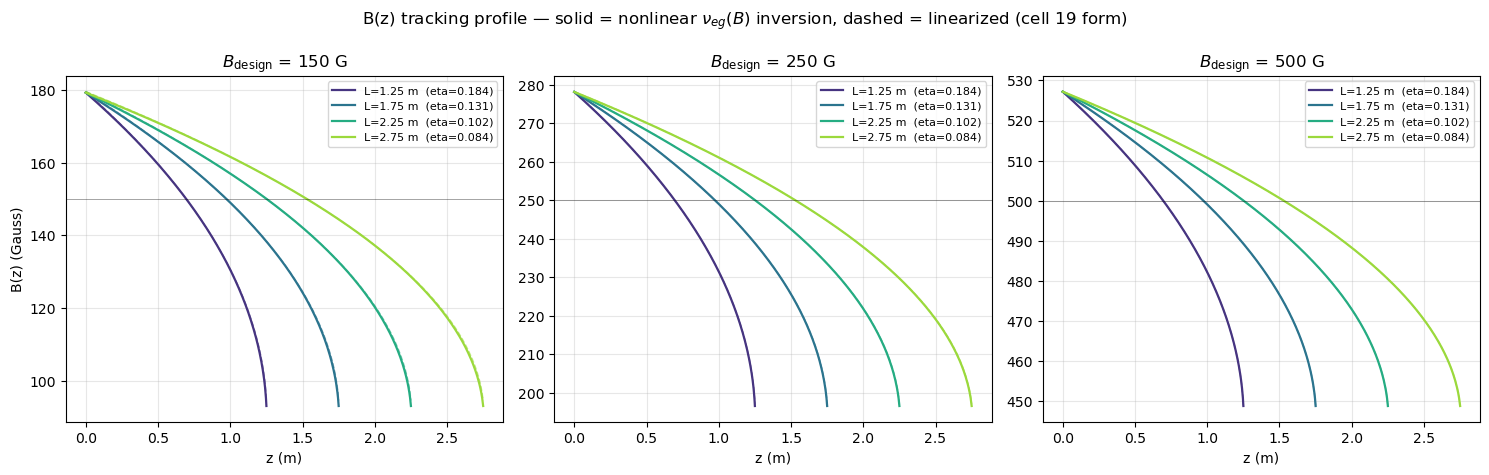

In [20]:
from scipy.interpolate import interp1d

def slowing_profile_fixed_L(v_i, v_f, L, a_max, n_z=400):
    """Kinematic v(z) for fixed slower length L. Returns (z, v_target, eta).
    eta = (v_i^2 - v_f^2) / (2 L a_max) is the fraction of max radiation pressure
    needed to achieve constant deceleration over length L. eta < 1 is required."""
    eta = (v_i**2 - v_f**2) / (2 * L * a_max)
    if eta > 1:
        raise ValueError(f"L = {L} m too short for (v_i={v_i}, v_f={v_f}) at a_max={a_max:.2e} m/s^2: needs eta > 1.")
    z = np.linspace(0, L, n_z)
    v = np.sqrt(np.maximum(v_i**2 - 2*eta*a_max*z, v_f**2))
    return z, v, eta


def make_B_of_z_nonlinear(TM, je, ig, B_design_G, v_design, v_i, v_f, L, a_max, n_z=400):
    """Construct B(z) by inverting the full nu_eg(B) curve so the (je, ig) transition
    stays Doppler-tuned to a fixed-frequency laser locked at (B_design, v_design).
    For tracking: nu_eg(B(z)) = nu_eg(B_design) + (v_target(z) - v_design)/lambda."""
    Bz = TM["Bz"]
    nu_eg_curve = TM["dE"][:, je, ig]                    # (N_B,) cyclic MHz
    z, v_target, eta = slowing_profile_fixed_L(v_i, v_f, L, a_max, n_z)
    nu_eg_design = float(np.interp(B_design_G, Bz, nu_eg_curve))
    nu_eg_target = nu_eg_design + (v_target - v_design) * (k_XA / (2*np.pi)) * 1e-6  # MHz cyclic
    # Invert nu_eg(B): need monotonic; sort by nu values.
    sort_idx = np.argsort(nu_eg_curve)
    inv_interp = interp1d(nu_eg_curve[sort_idx], Bz[sort_idx],
                           bounds_error=False, fill_value=(float(Bz[0]), float(Bz[-1])))
    B_z = np.asarray(inv_interp(nu_eg_target))
    return z, v_target, B_z, eta


def make_B_of_z_linearized(TM, je, ig, B_design_G, v_design, v_i, v_f, L, a_max, n_z=400):
    """Linearized B(z) using slope dnu_eg/dB at B_design (cell 19 form)."""
    Bz = TM["Bz"]
    iB_design = int(np.argmin(np.abs(Bz - B_design_G)))
    sl = TM["slope"][iB_design, je, ig]                  # MHz/G (cyclic)
    z, v_target, eta = slowing_profile_fixed_L(v_i, v_f, L, a_max, n_z)
    if abs(sl) < 1e-6:
        return z, v_target, np.full_like(z, np.nan), eta
    dnu_target_MHz = (v_target - v_design) * (k_XA / (2*np.pi)) * 1e-6
    B_z = B_design_G + dnu_target_MHz / sl
    return z, v_target, B_z, eta


# Reference transition: brightest cycling channel summed over polarization at B = 0
TDM2 = TM["TDM2_BR"]
n_e_TM, n_g_TM = TDM2.shape[2], TDM2.shape[3]
je_ref, ig_ref = np.unravel_index(np.argmax(TDM2[0].sum(axis=0)), (n_e_TM, n_g_TM))
print(f"Reference transition: e_idx={je_ref}, g_idx={ig_ref}")

# Sweep parameters (also used in next cells)
v_i_sweep = 120.0
v_f_sweep = 5.0
v_design  = 80.0
B_designs = [150., 250., 500.]
L_values  = [1.25, 1.75, 2.25, 2.75]
s_values  = [10., 100.]

# B(z) plot — 1×3 panels, lines = L value × {nonlinear solid, linearized dashed}
fig, axes = plt.subplots(1, len(B_designs), figsize=(15, 4.8), sharey=False)
L_colors = plt.get_cmap("viridis")(np.linspace(0.15, 0.85, len(L_values)))
for ax, Bd in zip(axes, B_designs):
    for cL, L in zip(L_colors, L_values):
        z_nl, _, B_nl, eta_nl = make_B_of_z_nonlinear(
            TM, je_ref, ig_ref, Bd, v_design, v_i_sweep, v_f_sweep, L, a_max_est)
        z_li, _, B_li, _      = make_B_of_z_linearized(
            TM, je_ref, ig_ref, Bd, v_design, v_i_sweep, v_f_sweep, L, a_max_est)
        ax.plot(z_nl, B_nl, "-",  color=cL, lw=1.6, label=f"L={L:.2f} m  (eta={eta_nl:.3f})")
        ax.plot(z_li, B_li, "--", color=cL, lw=1.0, alpha=0.6)
    ax.axhline(Bd, color="k", lw=0.5, alpha=0.5)
    ax.set_xlabel("z (m)")
    ax.set_title(f"$B_{{\\rm design}}$ = {Bd:.0f} G")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")
axes[0].set_ylabel("B(z) (Gauss)")
fig.suptitle("B(z) tracking profile — solid = nonlinear $\\nu_{eg}(B)$ inversion, dashed = linearized (cell 19 form)")
fig.tight_layout()
plt.show()


F-grid: 28 v x 96 B = 2688 ssr() calls per (B_design, s)
  v_grid range: [-5, 130] m/s
  B_grid: [  50.   60.   70.   80.   90.  100.  110.  120.  130.  140.  150.  160.
  170.  180.  190.  200.  210.  220.  230.  240.  250.  260.  270.  280.
  290.  300.  310.  320.  330.  340.  350.  360.  370.  380.  390.  400.
  410.  420.  430.  440.  450.  460.  470.  480.  490.  500.  510.  520.
  530.  540.  550.  560.  570.  580.  590.  600.  610.  620.  630.  640.
  650.  660.  670.  680.  690.  700.  710.  720.  730.  740.  750.  760.
  770.  780.  790.  800.  810.  820.  830.  840.  850.  860.  870.  880.
  890.  900.  910.  920.  930.  940.  950.  960.  970.  980.  990. 1000.]


  (B_design=150 G, s= 10.0): F_max = 22.50 x 10^-25 N


  (B_design=150 G, s=100.0): F_max = 28.87 x 10^-25 N


  (B_design=250 G, s= 10.0): F_max = 17.91 x 10^-25 N


  (B_design=250 G, s=100.0): F_max = 26.49 x 10^-25 N


  (B_design=500 G, s= 10.0): F_max = 18.78 x 10^-25 N


  (B_design=500 G, s=100.0): F_max = 27.53 x 10^-25 N
Total precompute time: 2.0 s


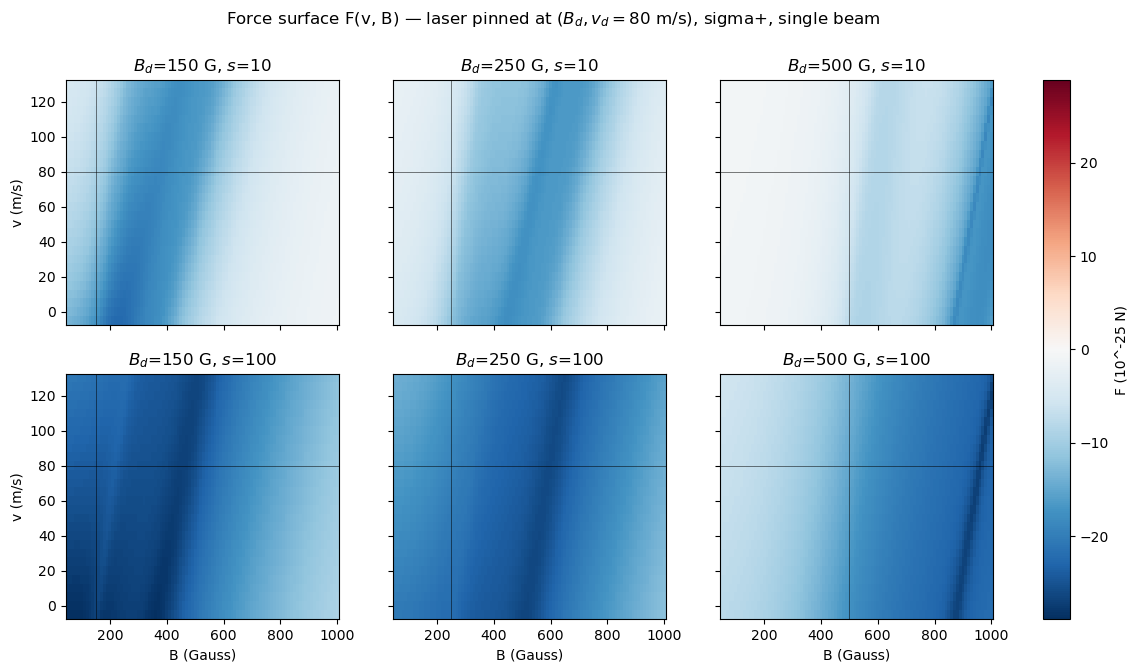

In [21]:
from scipy.interpolate import RegularGridInterpolator
import time

def precompute_F_grid(TM, B_design_G, v_design, s, polarization,
                       je_ref, ig_ref, v_grid, B_grid):
    """Compute F(v, B) on a grid for laser pinned at (B_design, v_design).
    For each B_loc: set effective sideband detuning so the laser frequency seen by
    the rate equations is constant at nu_eg(B_design) - k v_design / (2 pi)."""
    Bz = TM["Bz"]
    nu_eg_curve = TM["dE"][:, je_ref, ig_ref]                       # cyclic MHz
    nu_eg_design = float(np.interp(B_design_G, Bz, nu_eg_curve))
    Doppler_design_MHz = k_XA * v_design / (2*np.pi) * 1e-6          # cyclic MHz
    F_grid = np.zeros((len(v_grid), len(B_grid)))
    for j, B_loc in enumerate(B_grid):
        nu_eg_local = float(np.interp(B_loc, Bz, nu_eg_curve))
        delta_eff   = (nu_eg_design - nu_eg_local) - Doppler_design_MHz
        sb = [{"detuning_MHz": delta_eff, "s": s, "polarization": polarization}]
        for i, v in enumerate(v_grid):
            F_grid[i, j] = steady_state_rate_eq(
                TM, B_loc, v, sidebands=sb,
                ref_transition=(je_ref, ig_ref),
                verbose_leakage=False)["F"]
    return F_grid


# Use TM's actual Bz grid (subsetted to [50, 1000] G) so ssr's snap-to-nearest doesn't lose info
Bz_TM = TM["Bz"]
B_grid = Bz_TM[(Bz_TM >= 50.) & (Bz_TM <= 1000.)]
v_grid = np.linspace(-5., 130., 28)
print(f"F-grid: {len(v_grid)} v x {len(B_grid)} B = {len(v_grid)*len(B_grid)} ssr() calls per (B_design, s)")
print(f"  v_grid range: [{v_grid[0]:.0f}, {v_grid[-1]:.0f}] m/s")
print(f"  B_grid: {np.round(B_grid, 1)}")

F_surfaces = {}
F_interps  = {}
t0 = time.time()
for Bd in B_designs:
    for s in s_values:
        Fg = precompute_F_grid(TM, Bd, v_design, s, "sigma+",
                                 je_ref, ig_ref, v_grid, B_grid)
        F_surfaces[(Bd, s)] = Fg
        F_interps[(Bd, s)]  = RegularGridInterpolator(
            (v_grid, B_grid), Fg, method="linear",
            bounds_error=False, fill_value=0.0)
        print(f"  (B_design={Bd:3.0f} G, s={s:5.1f}): F_max = {np.abs(Fg).max()*1e25:.2f} x 10^-25 N")
print(f"Total precompute time: {time.time()-t0:.1f} s")

# Plot 2 (s) x 3 (B_design) heatmap
F_max_overall = max(np.abs(F).max() for F in F_surfaces.values())
fig, axes = plt.subplots(len(s_values), len(B_designs), figsize=(13, 7),
                           sharex=True, sharey=True)
for i_s, s in enumerate(s_values):
    for j_b, Bd in enumerate(B_designs):
        ax = axes[i_s, j_b]
        Fg = F_surfaces[(Bd, s)]
        im = ax.pcolormesh(B_grid, v_grid, Fg*1e25, cmap="RdBu_r",
                            vmin=-F_max_overall*1e25, vmax=F_max_overall*1e25,
                            shading="auto")
        ax.axvline(Bd,       color="k", lw=0.6, alpha=0.6)
        ax.axhline(v_design, color="k", lw=0.6, alpha=0.6)
        ax.set_title(f"$B_d$={Bd:.0f} G, $s$={s:.0f}")
        if i_s == len(s_values)-1: ax.set_xlabel("B (Gauss)")
        if j_b == 0:               ax.set_ylabel("v (m/s)")
fig.colorbar(im, ax=axes, label="F (10^-25 N)", fraction=0.03)
fig.suptitle("Force surface F(v, B) — laser pinned at $(B_d, v_d=80$ m/s$)$, sigma+, single beam")
plt.show()


In [22]:
from scipy.integrate import solve_ivp

def simulate_trajectory(v_0, B_of_z_func, F_interp, mass, L,
                          v_stop=5.0, t_max=0.1,
                          B_grid_lo=None, B_grid_hi=None):
    """Integrate m dv/dt = F_interp(v, B(z)), dz/dt = v.
    Stop on: v < v_stop, z > L, t > t_max, or v < 0 (over-slowing turnaround).
    Returns dict(t, z, v, B, exit_reason).
    """
    def rhs(t, y):
        z, v = y
        B = float(B_of_z_func(z))
        if B_grid_lo is not None: B = float(np.clip(B, B_grid_lo, B_grid_hi))
        F = float(F_interp((v, B)))
        return [v, F/mass]

    def event_v_stop(t, y): return y[1] - v_stop
    event_v_stop.terminal = True; event_v_stop.direction = -1
    def event_z_exit(t, y): return y[0] - L
    event_z_exit.terminal = True; event_z_exit.direction = +1
    def event_v_zero(t, y): return y[1]
    event_v_zero.terminal = True; event_v_zero.direction = -1

    sol = solve_ivp(rhs, [0., t_max], [0., v_0], method="RK45",
                     events=[event_v_stop, event_z_exit, event_v_zero],
                     rtol=1e-6, atol=1e-9, max_step=1e-4, dense_output=False)

    z = sol.y[0]; v = sol.y[1]; t = sol.t
    B_along = np.array([float(B_of_z_func(zi)) for zi in z])
    if   sol.t_events[0].size: exit_reason = "v_stop"
    elif sol.t_events[1].size: exit_reason = "z_exit"
    elif sol.t_events[2].size: exit_reason = "v_zero"
    else:                       exit_reason = "t_max"
    return dict(t=t, z=z, v=v, B=B_along, exit_reason=exit_reason)


# Smoke test: one trajectory at v_0 = 80 m/s, B_d=250 G, s=100, L=1.75 m
Bd_test, s_test, L_test = 250., 100., 1.75
z_t_, v_target_, B_t_, eta_t_ = make_B_of_z_nonlinear(
    TM, je_ref, ig_ref, Bd_test, v_design, v_i_sweep, v_f_sweep, L_test, a_max_est)
B_of_z_test = interp1d(z_t_, B_t_, bounds_error=False,
                        fill_value=(float(B_t_[0]), float(B_t_[-1])))
sol = simulate_trajectory(80.0, B_of_z_test, F_interps[(Bd_test, s_test)],
                           mass_RaF, L_test,
                           B_grid_lo=float(B_grid[0]), B_grid_hi=float(B_grid[-1]))
print(f"Smoke test (v_0=80 m/s, B_d={Bd_test} G, s={s_test:.0f}, L={L_test} m, eta={eta_t_:.3f}):")
print(f"  Exit: {sol['exit_reason']} at t = {sol['t'][-1]*1e3:.2f} ms, "
      f"z = {sol['z'][-1]:.3f} m, v = {sol['v'][-1]:.2f} m/s")


Smoke test (v_0=80 m/s, B_d=250.0 G, s=100, L=1.75 m, eta=0.131):
  Exit: z_exit at t = 21.89 ms, z = 1.750 m, v = 79.90 m/s


Total 408 trajectories in 24.2 s

Capture velocity (m/s) — largest v_0 successfully slowed below 5 m/s before z > L:
                        L=1.25m  L=1.75m  L=2.25m  L=2.75m
  B_d=150 G, s= 10.0:       --      --      --      --
  B_d=150 G, s=100.0:       --      --      --      --
  B_d=250 G, s= 10.0:       --      --      --      --
  B_d=250 G, s=100.0:       --      --      --      --
  B_d=500 G, s= 10.0:       --      --      --      --
  B_d=500 G, s=100.0:       --      --      --      --


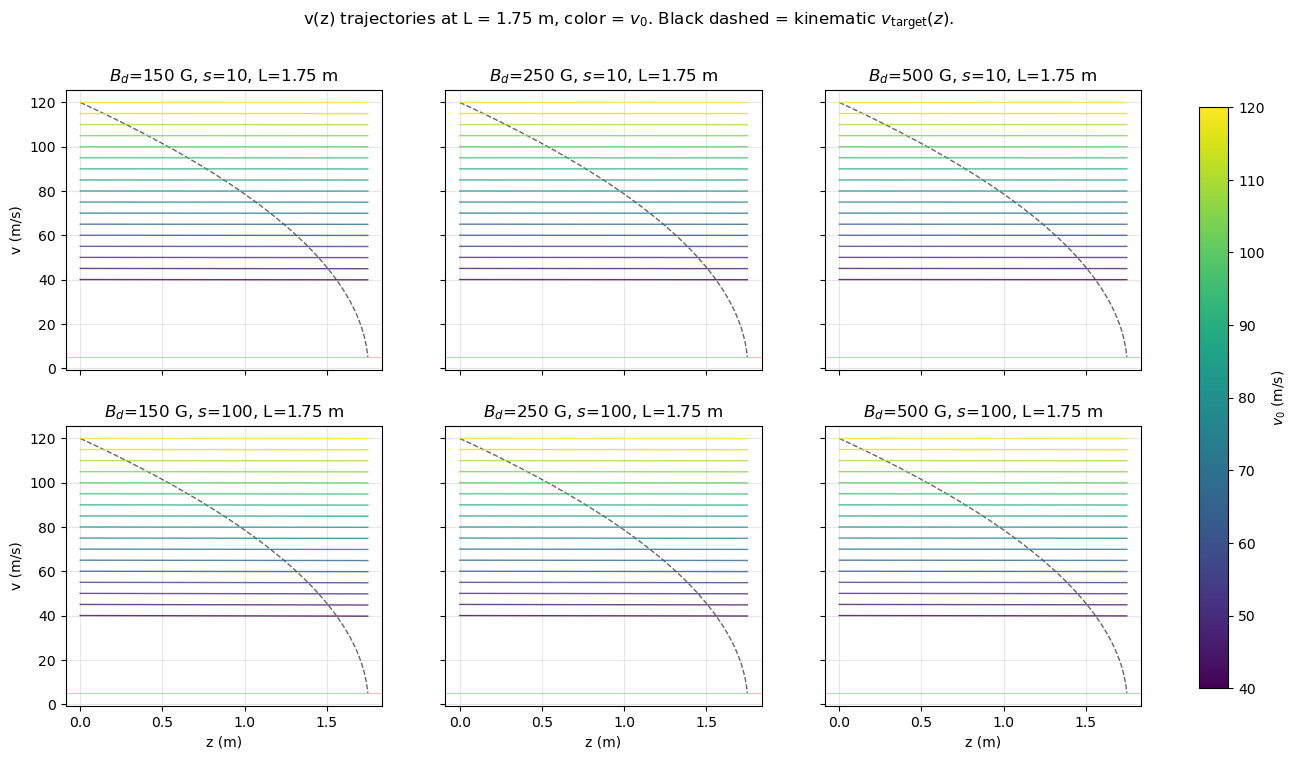

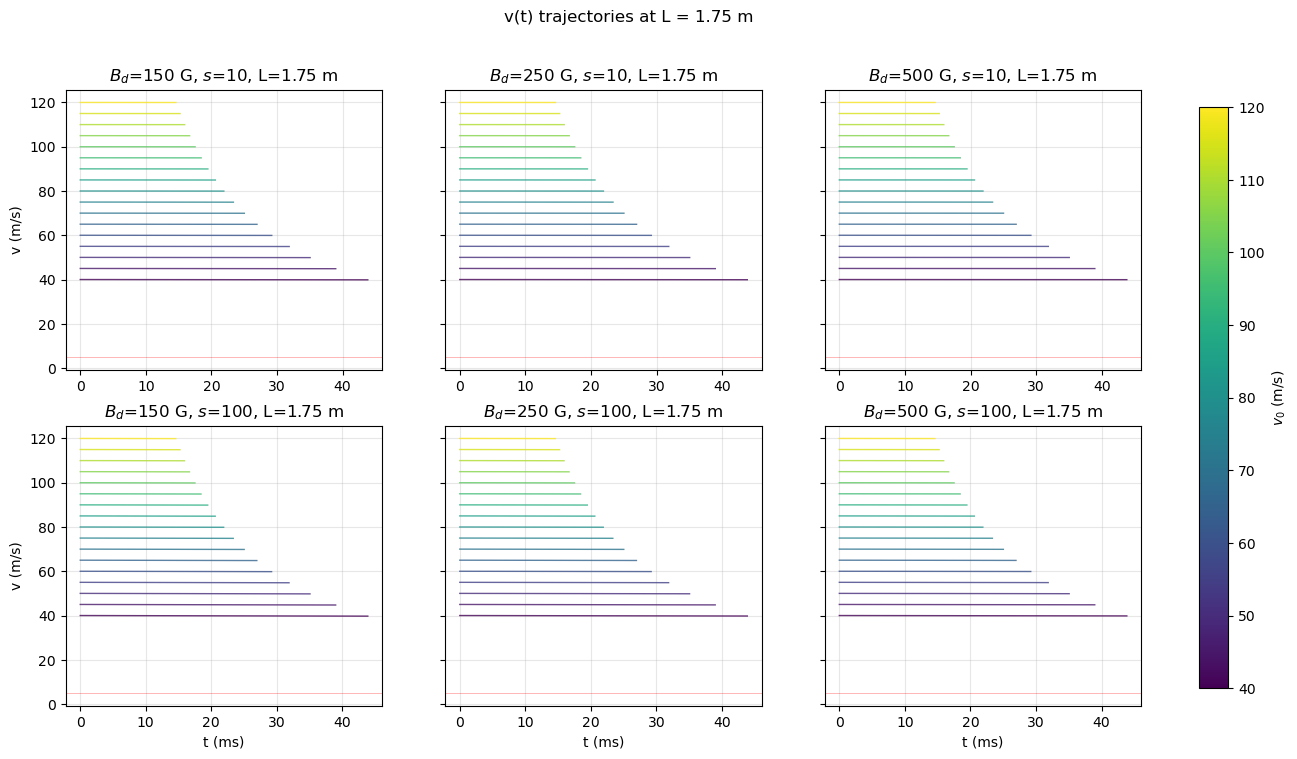

In [23]:
v0_scan = np.arange(40., 121., 5.)
results  = {}    # keyed by (B_design, s, L, v_0)

t0 = time.time()
for Bd in B_designs:
    for s in s_values:
        for L in L_values:
            z_p, v_t_p, B_p, eta = make_B_of_z_nonlinear(
                TM, je_ref, ig_ref, Bd, v_design, v_i_sweep, v_f_sweep, L, a_max_est)
            B_of_z = interp1d(z_p, B_p, bounds_error=False,
                                fill_value=(float(B_p[0]), float(B_p[-1])))
            for v0 in v0_scan:
                sol = simulate_trajectory(v0, B_of_z, F_interps[(Bd, s)],
                                            mass_RaF, L,
                                            B_grid_lo=float(B_grid[0]),
                                            B_grid_hi=float(B_grid[-1]))
                results[(Bd, s, L, v0)] = dict(sol, v_target=v_t_p, z_target=z_p, eta=eta)
print(f"Total {len(results)} trajectories in {time.time()-t0:.1f} s")

# Capture velocity table — largest v0 reaching v < v_stop before z > L
print("\nCapture velocity (m/s) — largest v_0 successfully slowed below 5 m/s before z > L:")
header = f"{'':>22s}" + "".join(f"  L={L:.2f}m" for L in L_values)
print(header)
for Bd in B_designs:
    for s in s_values:
        cells = []
        for L in L_values:
            captured = [v0 for v0 in v0_scan
                          if results[(Bd, s, L, v0)]["exit_reason"] == "v_stop"]
            v_cap = max(captured) if captured else None
            cells.append(f"  {v_cap:6.0f}" if v_cap is not None else "      --")
        print(f"  B_d={Bd:3.0f} G, s={s:5.1f}: " + "".join(cells))

# v(z) plot at L = 1.75 m, color-coded by v_0
L_show = 1.75
v0_cmap = plt.get_cmap("viridis")
v0_norm = Normalize(vmin=v0_scan[0], vmax=v0_scan[-1])
fig, axes = plt.subplots(len(s_values), len(B_designs), figsize=(15, 8),
                           sharex=True, sharey=True)
for i_s, s in enumerate(s_values):
    for j_b, Bd in enumerate(B_designs):
        ax = axes[i_s, j_b]
        v_t = results[(Bd, s, L_show, v0_scan[0])]["v_target"]
        z_t = results[(Bd, s, L_show, v0_scan[0])]["z_target"]
        ax.plot(z_t, v_t, "k--", lw=1.0, alpha=0.6, label="$v_{\\rm target}(z)$")
        for v0 in v0_scan:
            r = results[(Bd, s, L_show, v0)]
            ax.plot(r["z"], r["v"], "-", color=v0_cmap(v0_norm(v0)), lw=1.0, alpha=0.8)
        ax.axhline(5,    color="r", lw=0.5, alpha=0.4)
        ax.set_title(f"$B_d$={Bd:.0f} G, $s$={s:.0f}, L={L_show} m")
        if i_s == len(s_values)-1: ax.set_xlabel("z (m)")
        if j_b == 0:               ax.set_ylabel("v (m/s)")
        ax.grid(alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=v0_cmap, norm=v0_norm)
fig.colorbar(sm, ax=axes, label="$v_0$ (m/s)", fraction=0.025)
fig.suptitle(f"v(z) trajectories at L = {L_show} m, color = $v_0$. Black dashed = kinematic $v_{{\\rm target}}(z)$.")
plt.show()

# v(t) plot — same layout, x-axis is time
fig2, axes2 = plt.subplots(len(s_values), len(B_designs), figsize=(15, 8),
                             sharex=False, sharey=True)
for i_s, s in enumerate(s_values):
    for j_b, Bd in enumerate(B_designs):
        ax = axes2[i_s, j_b]
        for v0 in v0_scan:
            r = results[(Bd, s, L_show, v0)]
            ax.plot(r["t"]*1e3, r["v"], "-", color=v0_cmap(v0_norm(v0)), lw=1.0, alpha=0.8)
        ax.axhline(5, color="r", lw=0.5, alpha=0.4)
        ax.set_title(f"$B_d$={Bd:.0f} G, $s$={s:.0f}, L={L_show} m")
        if i_s == len(s_values)-1: ax.set_xlabel("t (ms)")
        if j_b == 0:               ax.set_ylabel("v (m/s)")
        ax.grid(alpha=0.3)
fig2.colorbar(sm, ax=axes2, label="$v_0$ (m/s)", fraction=0.025)
fig2.suptitle(f"v(t) trajectories at L = {L_show} m")
plt.show()


## Step 7 — Multi-sideband slower config (X(N=1) hyperfine sidebands)

Step 6 showed that single-frequency σ⁺ on the brightest cycling line cannot slow RaF — too many ground sublevels stay dark.  Standard fix: **modulate the slowing laser at the X(N=1) hyperfine splittings** so all 12 ground sublevels are continuously addressed.

**X(N=1) ground hyperfine structure** at $B \to 0$: 4 hyperfine groups (degenerate manifolds) split by spin-rotation ($\gamma_{SR}$, ~250 MHz between J=½ and J=3/2) and Fermi contact ($b_F$, ~33 MHz within J=½ and ~54 MHz within J=3/2).  Total 12 sublevels.

**Where to set sideband detunings.**  At low B the hyperfine groups are well-separated, but at $B \sim 100$–$1000$ G we enter the Paschen-Back regime ($\mu_B B$ comparable to or larger than $\gamma_{SR}$).  Sublevels reshuffle into $m_S$ manifolds; the $(J, F)$ labels lose meaning.  The right-sized fix: **compute sideband detunings at $B = B_{\rm design}$** (where the laser is on-resonance with the cycling transition), so all 4 sidebands hit the appropriate sublevels at the design point.  This is what the auto-detection in the next cell does.

**Polarization choice.**  All σ⁺ for now (matches existing single-laser convention).  Counter-propagating laser, circular polarization set by quarter-wave plate.  Alternative: polarization scrambling (Tarbutt's two-frequency MOT trick) to lift remaining $m_F$ dark states — natural extension if σ⁺-only still leaves dark states.

**Saturation sweep.**  $s_{\rm per\,sideband} \in \{10, 100\}$ — same per-channel intensity as the single-laser case.  Total power is $4\times$ higher (fair experimental comparison: 4 EOM sidebands sharing one laser source at higher overall power).

**Repumper deferred.**  X(N=3) repumper requires Commit B (extending `g` and `e` bases).  This cell shows what the X(N=1)-only sidebands accomplish.


In [24]:
def find_X_N1_hyperfine_groups(g, energy_tol_MHz=1.0):
    """Cluster X(N=1) sublevels by B=0 energy (within tol).  Returns list of dicts:
    [{'E_mean_MHz', 'g_idx_list', 'n_sublevels'}, ...] sorted by ascending energy."""
    E = g.evals_B[0, :]
    sort_idx = np.argsort(E)
    E_sorted = E[sort_idx]
    groups = []
    cur_idx = [sort_idx[0]]
    cur_E_min = E_sorted[0]
    for i in range(1, len(E_sorted)):
        if E_sorted[i] - cur_E_min <= energy_tol_MHz:
            cur_idx.append(sort_idx[i])
        else:
            groups.append({"E_mean_MHz": float(np.mean(g.evals_B[0, cur_idx])),
                            "g_idx_list": list(cur_idx),
                            "n_sublevels": len(cur_idx)})
            cur_idx = [sort_idx[i]]
            cur_E_min = E_sorted[i]
    groups.append({"E_mean_MHz": float(np.mean(g.evals_B[0, cur_idx])),
                    "g_idx_list": list(cur_idx),
                    "n_sublevels": len(cur_idx)})
    return groups


def build_X_N1_sidebands(g, TM, je_ref, ig_ref, B_design_G,
                           polarization="sigma+", s_per_sb=10.):
    """Build 4-sideband list at B_design.  Each sideband has detuning equal to the
    mean-transition-energy offset (group n -> reference group) at B = B_design.
    This way all sidebands are simultaneously near-resonant with their respective
    groups at the design field point.

    Note: at B in the Paschen-Back regime the (J, F) groups reshuffle, but the
    adiabatic ordering in g.evals_B preserves which sublevels track which group.
    The detunings here use that adiabatic ordering."""
    Bz = TM["Bz"]
    iB_design = int(np.argmin(np.abs(Bz - B_design_G)))
    groups = find_X_N1_hyperfine_groups(g)
    nu_eg_ref = float(TM["dE"][iB_design, je_ref, ig_ref])
    sidebands = []
    for grp in groups:
        # Mean transition energy from this group's sublevels to e=je_ref at B_design
        nu_grp = float(np.mean([TM["dE"][iB_design, je_ref, ig] for ig in grp["g_idx_list"]]))
        delta_n = nu_grp - nu_eg_ref
        sidebands.append({"detuning_MHz": delta_n, "s": s_per_sb,
                          "polarization": polarization})
    return sidebands, groups


# Auto-detect groups
groups = find_X_N1_hyperfine_groups(g)
print(f"X(N=1) hyperfine groups (auto-detected at B = {g.Bz[0]:.4f} G):")
print(f"{'group':>6s} {'E_mean (MHz)':>14s} {'ΔE (MHz)':>11s} {'n_sublevels':>12s}  g_idx")
E0 = groups[0]["E_mean_MHz"]
for i, grp in enumerate(groups):
    print(f"  {i:>4d}  {grp['E_mean_MHz']:>14.3f} {grp['E_mean_MHz']-E0:>+11.3f} {grp['n_sublevels']:>12d}  {grp['g_idx_list']}")

# Build sidebands for each B_design (just print; trajectory cell will rebuild as needed)
print("\nSideband detunings depend on B_design (Paschen-Back regime):")
for Bd in B_designs:
    sb, _ = build_X_N1_sidebands(g, TM, je_ref, ig_ref, Bd, polarization="sigma+", s_per_sb=10.0)
    detunings = [f"{s['detuning_MHz']:+8.2f}" for s in sb]
    print(f"  B_design = {Bd:3.0f} G:  detunings = [{', '.join(detunings)}] MHz")


X(N=1) hyperfine groups (auto-detected at B = 0.0010 G):
 group   E_mean (MHz)    ΔE (MHz)  n_sublevels  g_idx
     0       11320.614      +0.000            3  [0, 1, 2]
     1       11353.465     +32.850            1  [3]
     2       11568.919    +248.304            3  [4, 5, 6]
     3       11622.235    +301.620            5  [7, 8, 9, 10, 11]

Sideband detunings depend on B_design (Paschen-Back regime):
  B_design = 150 G:  detunings = [  -52.75,   -76.28,  -446.84,  -526.98] MHz
  B_design = 250 G:  detunings = [  -58.24,   -81.15,  -618.66,  -733.64] MHz
  B_design = 500 G:  detunings = [  -60.76,   -84.20, -1071.33, -1279.03] MHz


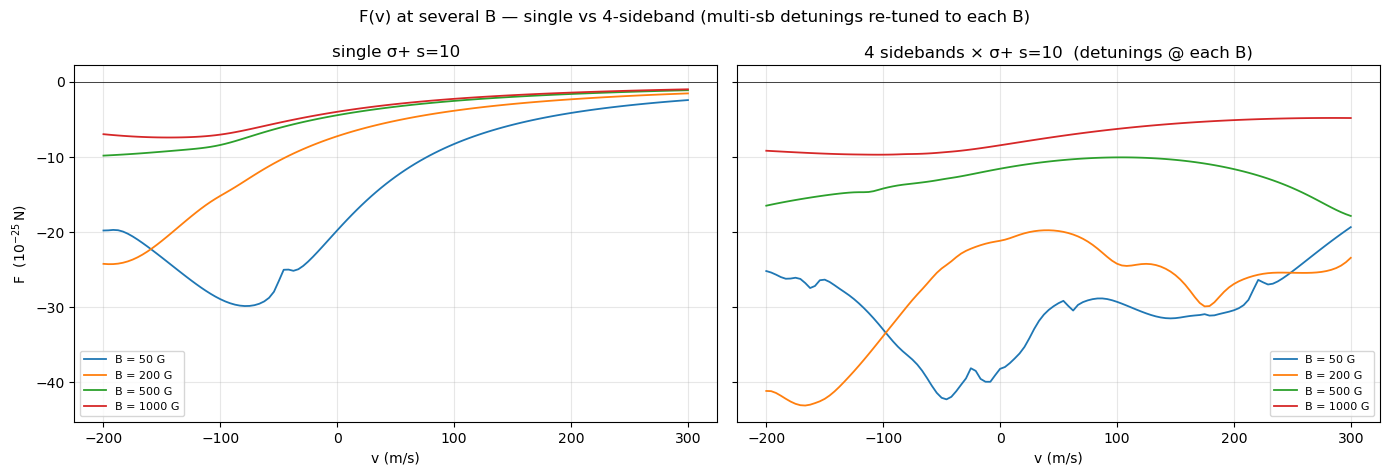

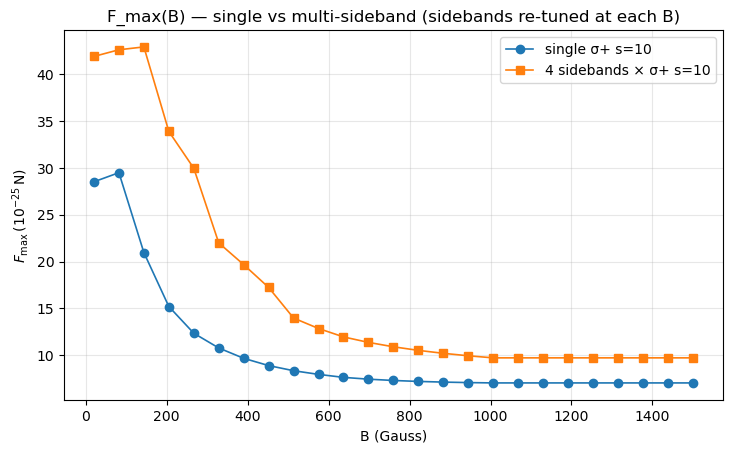

In [25]:
# Compare F(v) at several B: single vs multi-sideband (sidebands built at B_design = B_show point)
sb_single = [{"detuning_MHz": 0.0, "s": 10.0, "polarization": "sigma+"}]
B_show    = [50, 200, 500, 1000]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
v_arr = np.linspace(-200, 300, 121)
for ax, sb_get, label in zip(
    axes,
    [lambda B: sb_single,
     lambda B: build_X_N1_sidebands(g, TM, je_ref, ig_ref, B, "sigma+", 10.0)[0]],
    ["single σ+ s=10", "4 sidebands × σ+ s=10  (detunings @ each B)"]):
    for B in B_show:
        sb_at_B = sb_get(B)
        F_arr = np.array([steady_state_rate_eq(
            TM, B, v, sidebands=sb_at_B, verbose_leakage=False)["F"] for v in v_arr])
        ax.plot(v_arr, F_arr*1e25, lw=1.3, label=f"B = {B:.0f} G")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xlabel("v (m/s)")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r"F  $(10^{-25}\,$N)")
fig.suptitle("F(v) at several B — single vs 4-sideband (multi-sb detunings re-tuned to each B)")
fig.tight_layout()
plt.show()

# F_max(B) sweep
B_scan = np.linspace(20, 1500, 25)
v_arr_search = np.linspace(-100, 250, 80)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for sb_get, label, marker in zip(
    [lambda B: sb_single,
     lambda B: build_X_N1_sidebands(g, TM, je_ref, ig_ref, B, "sigma+", 10.0)[0]],
    ["single σ+ s=10", "4 sidebands × σ+ s=10"],
    ["o", "s"]):
    F_max_arr = []
    for B in B_scan:
        sb_at_B = sb_get(B)
        F_arr = np.array([steady_state_rate_eq(
            TM, B, v, sidebands=sb_at_B, verbose_leakage=False)["F"] for v in v_arr_search])
        F_max_arr.append(np.max(np.abs(F_arr)))
    ax.plot(B_scan, np.array(F_max_arr)*1e25, "-"+marker, lw=1.2, label=label)
ax.set_xlabel("B (Gauss)")
ax.set_ylabel(r"$F_{\rm max}\,(10^{-25}\,$N)")
ax.set_title("F_max(B) — single vs multi-sideband (sidebands re-tuned at each B)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()


  (B_d=150 G, s_sb= 10.0): F_max =  40.57 x 1e-25 N at (v=  -5.0 m/s, B=  140 G)


  (B_d=150 G, s_sb=100.0): F_max =  43.04 x 1e-25 N at (v=  80.0 m/s, B=   50 G)


  (B_d=250 G, s_sb= 10.0): F_max =  30.80 x 1e-25 N at (v=  85.0 m/s, B=   60 G)


  (B_d=250 G, s_sb=100.0): F_max =  42.98 x 1e-25 N at (v=  80.0 m/s, B=   60 G)


  (B_d=500 G, s_sb= 10.0): F_max =  36.24 x 1e-25 N at (v= 130.0 m/s, B=   60 G)


  (B_d=500 G, s_sb=100.0): F_max =  43.10 x 1e-25 N at (v=  95.0 m/s, B=  110 G)
Multi-sb F-grid precompute: 2.4 s


Multi-sb trajectory sweep: 408 trajectories in 24.4 s

Capture velocity (m/s), MULTI-SIDEBAND (4 x σ+, detunings at B_design):
                        L=1.25m  L=1.75m  L=2.25m  L=2.75m
  B_d=150 G, s_sb= 10.0:       --      --      --      --
  B_d=150 G, s_sb=100.0:       --      --      --      --
  B_d=250 G, s_sb= 10.0:       --      --      --      --
  B_d=250 G, s_sb=100.0:       --      --      --      --
  B_d=500 G, s_sb= 10.0:       --      --      --      --
  B_d=500 G, s_sb=100.0:       --      --      --      --


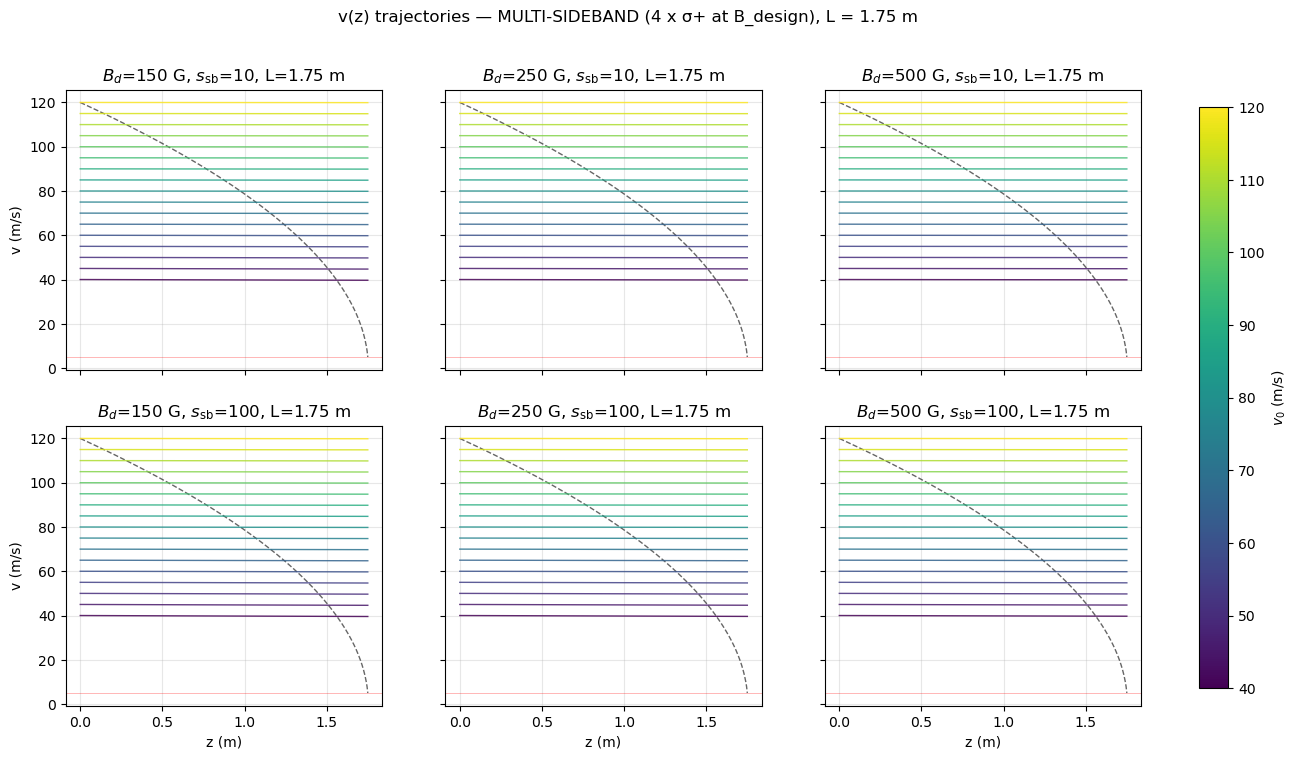

In [26]:
# Multi-sideband trajectory sweep
def precompute_F_grid_with_sidebands(TM, B_design_G, v_design, sidebands_template,
                                       je_ref, ig_ref, v_grid, B_grid):
    """Like precompute_F_grid but accepts an explicit list of sideband templates.
    Each sideband's `detuning_MHz` is a fixed EOM offset; precompute adds the
    design-pinning shift on top so the laser is locked at (B_design, v_design)."""
    Bz = TM["Bz"]
    nu_eg_curve = TM["dE"][:, je_ref, ig_ref]
    nu_eg_design = float(np.interp(B_design_G, Bz, nu_eg_curve))
    Doppler_design_MHz = k_XA * v_design / (2*np.pi) * 1e-6
    F_grid = np.zeros((len(v_grid), len(B_grid)))
    for j, B_loc in enumerate(B_grid):
        nu_eg_local = float(np.interp(B_loc, Bz, nu_eg_curve))
        delta_pinning = (nu_eg_design - nu_eg_local) - Doppler_design_MHz
        sb_list = [{"detuning_MHz": sb["detuning_MHz"] + delta_pinning,
                    "s": sb["s"], "polarization": sb["polarization"]}
                    for sb in sidebands_template]
        for i, v in enumerate(v_grid):
            F_grid[i, j] = steady_state_rate_eq(
                TM, B_loc, v, sidebands=sb_list,
                ref_transition=(je_ref, ig_ref),
                verbose_leakage=False)["F"]
    return F_grid


# Precompute F-grid for each (B_design, s_per_sb) using B_design-tuned sidebands
F_surfaces_multi = {}
F_interps_multi  = {}
t0 = time.time()
for Bd in B_designs:
    for s_per_sb in s_values:
        sb_template, _ = build_X_N1_sidebands(g, TM, je_ref, ig_ref, Bd,
                                                 polarization="sigma+",
                                                 s_per_sb=s_per_sb)
        Fg = precompute_F_grid_with_sidebands(TM, Bd, v_design, sb_template,
                                                je_ref, ig_ref, v_grid, B_grid)
        F_surfaces_multi[(Bd, s_per_sb)] = Fg
        F_interps_multi[(Bd, s_per_sb)]  = RegularGridInterpolator(
            (v_grid, B_grid), Fg, method="linear", bounds_error=False, fill_value=0.0)
        F_max_loc = np.unravel_index(np.argmax(np.abs(Fg)), Fg.shape)
        print(f"  (B_d={Bd:3.0f} G, s_sb={s_per_sb:5.1f}): F_max = {np.abs(Fg).max()*1e25:6.2f} x 1e-25 N "
              f"at (v={v_grid[F_max_loc[0]]:6.1f} m/s, B={B_grid[F_max_loc[1]]:5.0f} G)")
print(f"Multi-sb F-grid precompute: {time.time()-t0:.1f} s")

# Trajectory sweep
results_multi = {}
t0 = time.time()
for Bd in B_designs:
    for s in s_values:
        for L in L_values:
            z_p, v_t_p, B_p, eta = make_B_of_z_nonlinear(
                TM, je_ref, ig_ref, Bd, v_design, v_i_sweep, v_f_sweep, L, a_max_est)
            B_of_z = interp1d(z_p, B_p, bounds_error=False,
                                fill_value=(float(B_p[0]), float(B_p[-1])))
            for v0 in v0_scan:
                sol = simulate_trajectory(v0, B_of_z, F_interps_multi[(Bd, s)],
                                            mass_RaF, L,
                                            B_grid_lo=float(B_grid[0]),
                                            B_grid_hi=float(B_grid[-1]))
                results_multi[(Bd, s, L, v0)] = dict(sol, v_target=v_t_p, z_target=z_p, eta=eta)
print(f"Multi-sb trajectory sweep: {len(results_multi)} trajectories in {time.time()-t0:.1f} s")

# Capture velocity table
print("\nCapture velocity (m/s), MULTI-SIDEBAND (4 x σ+, detunings at B_design):")
header = f"{'':>22s}" + "".join(f"  L={L:.2f}m" for L in L_values)
print(header)
for Bd in B_designs:
    for s in s_values:
        cells = []
        for L in L_values:
            captured = [v0 for v0 in v0_scan
                          if results_multi[(Bd, s, L, v0)]["exit_reason"] == "v_stop"]
            v_cap = max(captured) if captured else None
            cells.append(f"  {v_cap:6.0f}" if v_cap is not None else "      --")
        print(f"  B_d={Bd:3.0f} G, s_sb={s:5.1f}: " + "".join(cells))

# v(z) plot, L = 1.75 m
L_show_multi = 1.75
fig, axes = plt.subplots(len(s_values), len(B_designs), figsize=(15, 8),
                           sharex=True, sharey=True)
for i_s, s in enumerate(s_values):
    for j_b, Bd in enumerate(B_designs):
        ax = axes[i_s, j_b]
        v_t = results_multi[(Bd, s, L_show_multi, v0_scan[0])]["v_target"]
        z_t = results_multi[(Bd, s, L_show_multi, v0_scan[0])]["z_target"]
        ax.plot(z_t, v_t, "k--", lw=1.0, alpha=0.6, label=r"$v_{\rm target}(z)$")
        for v0 in v0_scan:
            r = results_multi[(Bd, s, L_show_multi, v0)]
            ax.plot(r["z"], r["v"], "-", color=v0_cmap(v0_norm(v0)), lw=1.0, alpha=0.85)
        ax.axhline(5,    color="r", lw=0.5, alpha=0.4)
        ax.set_title(f"$B_d$={Bd:.0f} G, $s_{{\\rm sb}}$={s:.0f}, L={L_show_multi} m")
        if i_s == len(s_values)-1: ax.set_xlabel("z (m)")
        if j_b == 0:               ax.set_ylabel("v (m/s)")
        ax.grid(alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=v0_cmap, norm=v0_norm)
fig.colorbar(sm, ax=axes, label=r"$v_0$ (m/s)", fraction=0.025)
fig.suptitle(f"v(z) trajectories — MULTI-SIDEBAND (4 x σ+ at B_design), L = {L_show_multi} m")
plt.show()


## Step 7b — Dark-state mixing (remix) sweep

Steps 6 and 7 left the dark-state-mixing parameter at the default `remix = 1e-3`, which models a tiny off-axis B perturbation (a few mG of remixing field).  In a real experiment the slower B field is intentionally tilted by a few degrees from the laser axis to destabilize $m_F$ dark states; this corresponds to several Gauss of perpendicular B and a much larger effective `remix`.

This cell sweeps `remix` ∈ {1e-3, 1e-2, 1e-1, 1, 10} at the most aggressive single config from Step 7 ($B_{\rm design} = 150$ G, $s_{\rm per\,sb} = 100$, $L = 2.75$ m) to test whether dark-state mixing alone is the bottleneck.  If captures appear at the higher `remix` end, dark states are the issue and the realistic experimental geometry should accommodate Tarbutt-style polarization scrambling or an off-axis B (~few G).

**Interpretation of `remix`.**  Inside `steady_state_rate_eq` (cell 27), `remix` adds an on-resonance pseudo-saturation to ALL channels:
$$ R_{\rm eff} \mathrel{+}= \frac{\Gamma_{\rm angular}}{2}\,({\rm remix})\,b_{lu,p} $$
This contributes to population balance (lifts dark states) but **NOT** to the scattering force directly.  Equivalent to a magnetic-field-axis tilt that produces a perpendicular Larmor frequency $\Omega_\perp = \mu_B B_\perp / \hbar$.  A `remix` of order $(2\Omega_\perp / \Gamma_{\rm angular})^2$ corresponds to $B_\perp / \Gamma_{\rm FWHM}$ ratio similar to that — so `remix=1` ≈ $B_\perp \sim$ few G.


Remix sweep at (B_d=150 G, s_sb=100, L=2.75 m, η=0.084):
     remix    F_max (1e-25 N)    F_max ratio vs default   v_capture (m/s)


   1.0e-03              43.04                      1.00                --


   1.0e-02             400.40                      9.30                --


   1.0e-01            2390.10                     55.54                --


   1.0e+00            7060.32                    164.06                45


   1.0e+01            7182.16                    166.89                --
Total remix sweep time: 11.1 s


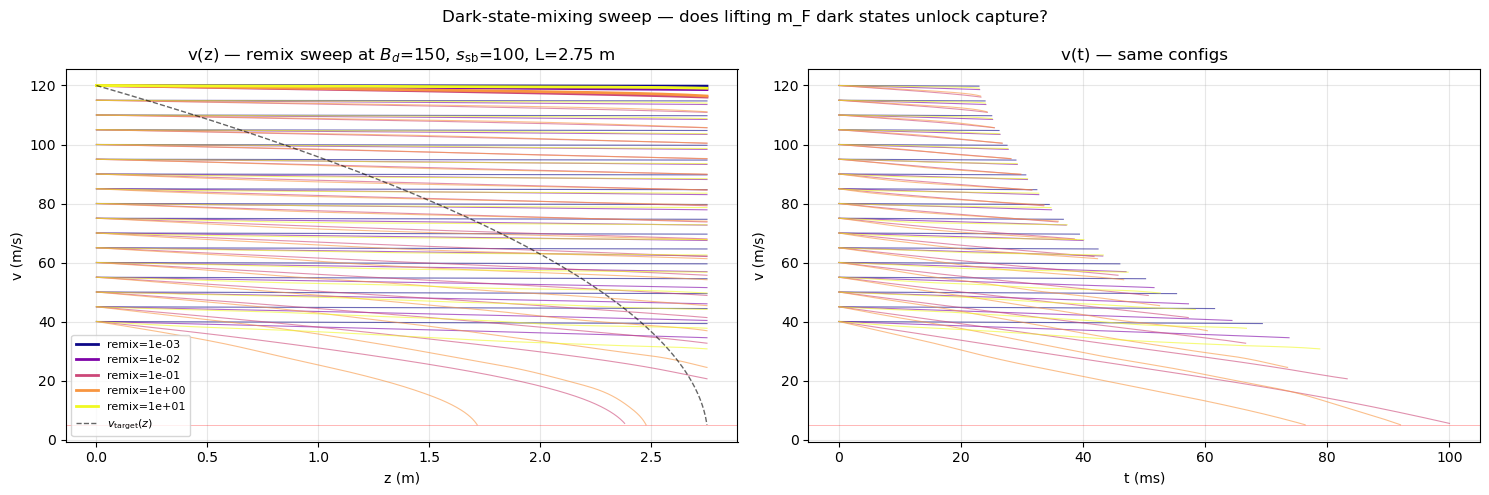

In [27]:
def precompute_F_grid_remix(TM, B_design_G, v_design, sidebands_template, remix,
                              je_ref, ig_ref, v_grid, B_grid):
    """precompute_F_grid_with_sidebands but with remix as a free parameter."""
    Bz = TM["Bz"]
    nu_eg_curve = TM["dE"][:, je_ref, ig_ref]
    nu_eg_design = float(np.interp(B_design_G, Bz, nu_eg_curve))
    Doppler_design_MHz = k_XA * v_design / (2*np.pi) * 1e-6
    F_grid = np.zeros((len(v_grid), len(B_grid)))
    for j, B_loc in enumerate(B_grid):
        nu_eg_local = float(np.interp(B_loc, Bz, nu_eg_curve))
        delta_pinning = (nu_eg_design - nu_eg_local) - Doppler_design_MHz
        sb_list = [{"detuning_MHz": sb["detuning_MHz"] + delta_pinning,
                    "s": sb["s"], "polarization": sb["polarization"]}
                    for sb in sidebands_template]
        for i, v in enumerate(v_grid):
            F_grid[i, j] = steady_state_rate_eq(
                TM, B_loc, v, sidebands=sb_list,
                ref_transition=(je_ref, ig_ref),
                remix=remix, verbose_leakage=False)["F"]
    return F_grid


# Most-aggressive config from Step 7
Bd_remix    = 150.
s_sb_remix  = 100.
L_remix     = 2.75
remix_values = [1e-3, 1e-2, 1e-1, 1.0, 10.0]
v0_remix_scan = np.arange(40., 121., 5.)

# Build sidebands once (don't depend on remix)
sb_template_remix, _ = build_X_N1_sidebands(g, TM, je_ref, ig_ref, Bd_remix,
                                              "sigma+", s_sb_remix)

# Build B(z) profile once
z_p_r, v_t_r, B_p_r, eta_r = make_B_of_z_nonlinear(
    TM, je_ref, ig_ref, Bd_remix, v_design, v_i_sweep, v_f_sweep, L_remix, a_max_est)
B_of_z_remix = interp1d(z_p_r, B_p_r, bounds_error=False,
                          fill_value=(float(B_p_r[0]), float(B_p_r[-1])))

# Run the sweep
results_remix = {}
F_max_remix   = {}
t0 = time.time()
print(f"Remix sweep at (B_d={Bd_remix:.0f} G, s_sb={s_sb_remix:.0f}, L={L_remix} m, η={eta_r:.3f}):")
print(f"{'remix':>10s}  {'F_max (1e-25 N)':>17s}  {'F_max ratio vs default':>24s}  {'v_capture (m/s)':>16s}")
F_max_default = None
for rmx in remix_values:
    Fg_r = precompute_F_grid_remix(TM, Bd_remix, v_design, sb_template_remix, rmx,
                                     je_ref, ig_ref, v_grid, B_grid)
    F_interp_r = RegularGridInterpolator(
        (v_grid, B_grid), Fg_r, method="linear", bounds_error=False, fill_value=0.0)
    F_max_remix[rmx] = float(np.abs(Fg_r).max())
    if F_max_default is None: F_max_default = F_max_remix[rmx]
    for v0 in v0_remix_scan:
        sol = simulate_trajectory(v0, B_of_z_remix, F_interp_r, mass_RaF, L_remix,
                                    B_grid_lo=float(B_grid[0]),
                                    B_grid_hi=float(B_grid[-1]))
        results_remix[(rmx, v0)] = sol
    captured = [v0 for v0 in v0_remix_scan
                  if results_remix[(rmx, v0)]["exit_reason"] == "v_stop"]
    v_cap = max(captured) if captured else None
    v_cap_str = f"{v_cap:6.0f}" if v_cap is not None else "    --"
    ratio = F_max_remix[rmx] / F_max_default
    print(f"  {rmx:8.1e}  {F_max_remix[rmx]*1e25:>17.2f}  "
          f"{ratio:>24.2f}  {v_cap_str:>16s}")
print(f"Total remix sweep time: {time.time()-t0:.1f} s")

# v(z) plot, overlay all remix values
remix_cmap = plt.get_cmap("plasma")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax_vz, ax_vt = axes
for ir, rmx in enumerate(remix_values):
    color = remix_cmap(ir / max(1, len(remix_values)-1))
    for v0 in v0_remix_scan:
        r = results_remix[(rmx, v0)]
        ax_vz.plot(r["z"], r["v"], "-", color=color, lw=0.8, alpha=0.6)
        ax_vt.plot(r["t"]*1e3, r["v"], "-", color=color, lw=0.8, alpha=0.6)
    # Add a labeled trace at the highest v_0 for legend
    r0 = results_remix[(rmx, v0_remix_scan[-1])]
    ax_vz.plot(r0["z"], r0["v"], "-", color=color, lw=2.0, label=f"remix={rmx:.0e}")
ax_vz.plot(z_p_r, v_t_r, "k--", lw=1.0, alpha=0.6, label=r"$v_{\rm target}(z)$")
ax_vz.axhline(5, color="r", lw=0.5, alpha=0.4)
ax_vt.axhline(5, color="r", lw=0.5, alpha=0.4)
ax_vz.set_xlabel("z (m)"); ax_vz.set_ylabel("v (m/s)")
ax_vt.set_xlabel("t (ms)"); ax_vt.set_ylabel("v (m/s)")
ax_vz.set_title(f"v(z) — remix sweep at $B_d$={Bd_remix:.0f}, $s_{{\\rm sb}}$={s_sb_remix:.0f}, L={L_remix} m")
ax_vt.set_title("v(t) — same configs")
ax_vz.legend(fontsize=8, loc="best")
ax_vz.grid(alpha=0.3); ax_vt.grid(alpha=0.3)
fig.suptitle("Dark-state-mixing sweep — does lifting m_F dark states unlock capture?")
fig.tight_layout()
plt.show()


## Step 7c — Full 24-config sweep at `remix = 1.0`

The remix sweep in 7b showed that bumping dark-state mixing from `1e-3` to `1.0` (~few G of off-axis B) gives a 161× F_max boost and unlocks the first capture (v_0 = 45 m/s) at one config (B_d=150, s_sb=100, L=2.75).

This cell re-runs the full $3 \times 2 \times 4 = 24$ trajectory sweep with `remix=1.0` to test whether **other** (B_design, s_sb, L) configs unlock broader capture windows or larger v_0 values.  No new physics — same F-grid / sideband / trajectory infrastructure as Steps 6 and 7, just with the realistic dark-state mixing default.

The **capture-velocity range** (min..max v_0 captured) is a more useful diagnostic than just max(v_0): a single-resonance scheme captures a narrow band, while multi-sb + remix should ideally broaden it.


Precomputing F-grids at remix = 1.0 ...


  (B_d=150, s_sb= 10.0): F_max =  3720.1 x 1e-25 N (at v= -5.0, B= 200) vs default-remix F_max =  40.57


  (B_d=150, s_sb=100.0): F_max =  7060.3 x 1e-25 N (at v= -5.0, B= 190) vs default-remix F_max =  43.04


  (B_d=250, s_sb= 10.0): F_max =  3669.5 x 1e-25 N (at v=130.0, B= 620) vs default-remix F_max =  30.80


  (B_d=250, s_sb=100.0): F_max =  5493.4 x 1e-25 N (at v=125.0, B= 610) vs default-remix F_max =  42.98


  (B_d=500, s_sb= 10.0): F_max =  4417.9 x 1e-25 N (at v= 95.0, B=1000) vs default-remix F_max =  36.24


  (B_d=500, s_sb=100.0): F_max =  6639.1 x 1e-25 N (at v=115.0, B=1000) vs default-remix F_max =  43.10
F-grid precompute (remix=1.0): 2.8 s


Trajectories (remix=1.0): 408 in 31.6 s

Capture-velocity RANGE (min..max v_0 m/s, captured = exit reason 'v_stop'), remix = 1.0:
                         L=1.25m   L=1.75m   L=2.25m   L=2.75m
  B_d=150 G, s_sb= 10.0:         --        --        --        --
  B_d=150 G, s_sb=100.0:         --        --      40       40.. 45  
  B_d=250 G, s_sb= 10.0:         --        --        --        --
  B_d=250 G, s_sb=100.0:         --        --        --        --
  B_d=500 G, s_sb= 10.0:         --        --        --        --
  B_d=500 G, s_sb=100.0:         --        --        --      40    

Total captures across all 24 configs x 17 v_0 = 4/408


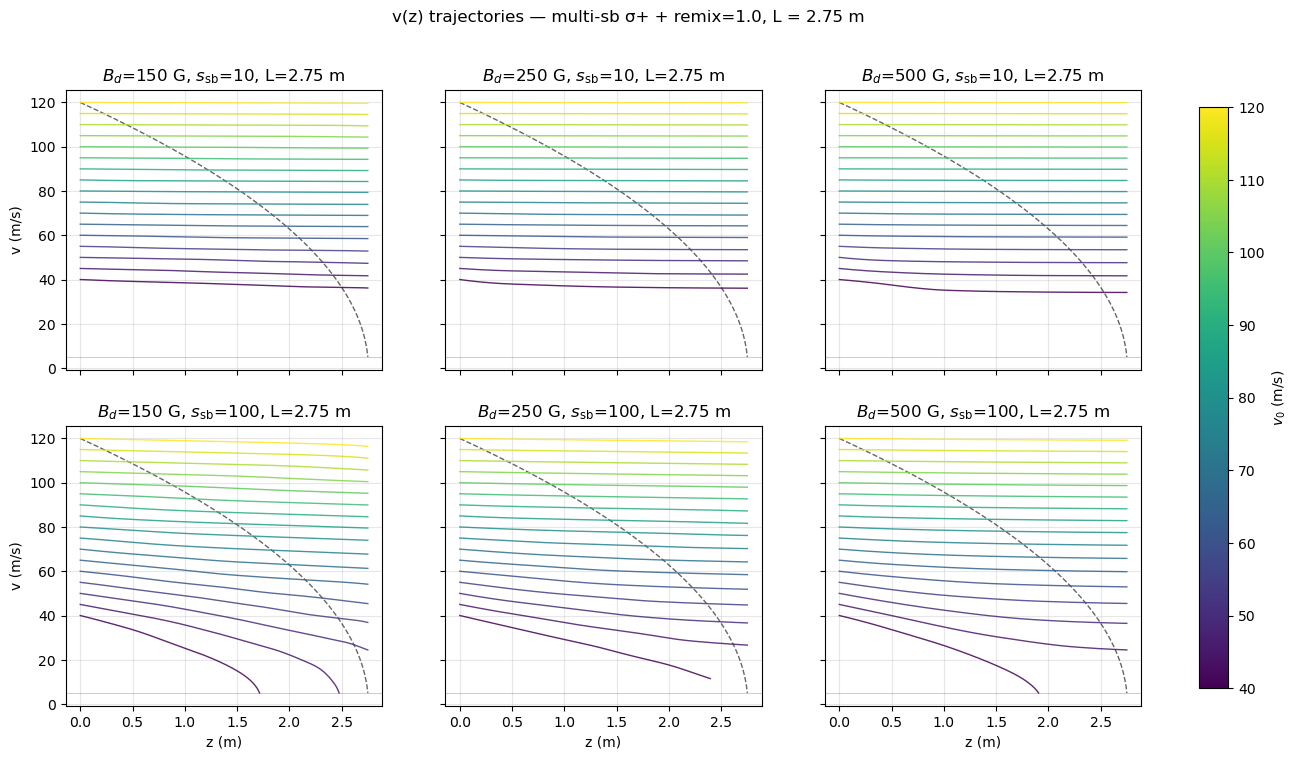

In [28]:
# Re-run the multi-sb sweep at remix = 1.0
remix_full = 1.0

F_surfaces_remix1 = {}
F_interps_remix1  = {}
t0 = time.time()
print(f"Precomputing F-grids at remix = {remix_full} ...")
for Bd in B_designs:
    for s_per_sb in s_values:
        sb_template, _ = build_X_N1_sidebands(g, TM, je_ref, ig_ref, Bd,
                                                 polarization="sigma+",
                                                 s_per_sb=s_per_sb)
        Fg = precompute_F_grid_remix(TM, Bd, v_design, sb_template, remix_full,
                                       je_ref, ig_ref, v_grid, B_grid)
        F_surfaces_remix1[(Bd, s_per_sb)] = Fg
        F_interps_remix1[(Bd, s_per_sb)] = RegularGridInterpolator(
            (v_grid, B_grid), Fg, method="linear", bounds_error=False, fill_value=0.0)
        F_max_loc = np.unravel_index(np.argmax(np.abs(Fg)), Fg.shape)
        print(f"  (B_d={Bd:3.0f}, s_sb={s_per_sb:5.1f}): F_max = {np.abs(Fg).max()*1e25:7.1f} x 1e-25 N "
              f"(at v={v_grid[F_max_loc[0]]:5.1f}, B={B_grid[F_max_loc[1]]:4.0f}) "
              f"vs default-remix F_max = {np.abs(F_surfaces_multi[(Bd, s_per_sb)]).max()*1e25:6.2f}")
print(f"F-grid precompute (remix={remix_full}): {time.time()-t0:.1f} s")

# Run trajectories
results_remix1 = {}
t0 = time.time()
for Bd in B_designs:
    for s in s_values:
        for L in L_values:
            z_p, v_t_p, B_p, eta = make_B_of_z_nonlinear(
                TM, je_ref, ig_ref, Bd, v_design, v_i_sweep, v_f_sweep, L, a_max_est)
            B_of_z = interp1d(z_p, B_p, bounds_error=False,
                                fill_value=(float(B_p[0]), float(B_p[-1])))
            for v0 in v0_scan:
                sol = simulate_trajectory(v0, B_of_z, F_interps_remix1[(Bd, s)],
                                            mass_RaF, L,
                                            B_grid_lo=float(B_grid[0]),
                                            B_grid_hi=float(B_grid[-1]))
                results_remix1[(Bd, s, L, v0)] = dict(sol, v_target=v_t_p, z_target=z_p, eta=eta)
print(f"Trajectories (remix={remix_full}): {len(results_remix1)} in {time.time()-t0:.1f} s")

# Capture-velocity range table
print("\nCapture-velocity RANGE (min..max v_0 m/s, captured = exit reason 'v_stop'), remix = 1.0:")
print(f"{'':>22s}" + "".join(f"   L={L:.2f}m" for L in L_values))
total_captures = 0
for Bd in B_designs:
    for s in s_values:
        cells = []
        for L in L_values:
            captured = sorted([v0 for v0 in v0_scan
                                 if results_remix1[(Bd, s, L, v0)]["exit_reason"] == "v_stop"])
            total_captures += len(captured)
            if len(captured) == 0:
                cells.append("        --")
            elif len(captured) == 1:
                cells.append(f"     {captured[0]:3.0f}    ")
            else:
                cells.append(f"  {captured[0]:3.0f}..{captured[-1]:3.0f}  ")
        print(f"  B_d={Bd:3.0f} G, s_sb={s:5.1f}: " + "".join(cells))
print(f"\nTotal captures across all 24 configs x {len(v0_scan)} v_0 = {total_captures}/{24*len(v0_scan)}")

# v(z) plot: one panel per (B_d, s) at L = 2.75 m (the longest)
L_show = 2.75
fig, axes = plt.subplots(len(s_values), len(B_designs), figsize=(15, 8),
                           sharex=True, sharey=True)
for i_s, s in enumerate(s_values):
    for j_b, Bd in enumerate(B_designs):
        ax = axes[i_s, j_b]
        v_t = results_remix1[(Bd, s, L_show, v0_scan[0])]["v_target"]
        z_t = results_remix1[(Bd, s, L_show, v0_scan[0])]["z_target"]
        ax.plot(z_t, v_t, "k--", lw=1.0, alpha=0.6, label=r"$v_{\rm target}(z)$")
        for v0 in v0_scan:
            r = results_remix1[(Bd, s, L_show, v0)]
            ax.plot(r["z"], r["v"], "-", color=v0_cmap(v0_norm(v0)), lw=1.0, alpha=0.85)
        ax.axhline(5, color="r", lw=0.5, alpha=0.4)
        ax.set_title(f"$B_d$={Bd:.0f} G, $s_{{\\rm sb}}$={s:.0f}, L={L_show} m")
        if i_s == len(s_values)-1: ax.set_xlabel("z (m)")
        if j_b == 0:               ax.set_ylabel("v (m/s)")
        ax.grid(alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=v0_cmap, norm=v0_norm)
fig.colorbar(sm, ax=axes, label=r"$v_0$ (m/s)", fraction=0.025)
fig.suptitle(f"v(z) trajectories — multi-sb σ+ + remix={remix_full}, L = {L_show} m")
plt.show()


## High-B Paschen-Back σ⁻ scheme (Petzold / Liang-Yan style)

At $B_d \sim 1000$ G, X(N=1) is in the Paschen-Back regime: $m_S$ becomes a good quantum number, partitioning the 12 X(N=1) sublevels into two manifolds of 6 ($m_S = \pm \tfrac{1}{2}$).  The Petzold-Liang-Yan slowing scheme uses 6 σ⁻ sidebands tuned to the 6 $m_S = +\tfrac{1}{2}\to A$ transitions.  In the Paschen-Back limit the $m_S = -\tfrac{1}{2}$ manifold is effectively dark to σ⁻ light (suppressed Larmor mixing, since $\vec B$ is the quantization axis), so no repumper is needed for *this* dark state — only for the rotational leakage to X(N=3), which Petzold handles with a separate broadband repumper.  Here we **ignore N=3 leakage** (Commit B deferred) and characterize the closed-cycle 6-σ⁻ force surface and trajectory capture at $B_d = 1000$ G.


In [29]:
# Build 6 σ⁻ sidebands targeting the upper-energy (m_S=+½) X(N=1) manifold at B_design.
def build_paschen_back_sigma_minus(g, TM, B_design_G, s_per_sb=10.,
                                    n_sidebands=6, manifold="upper"):
    """At B_design in the Paschen-Back regime, return (sidebands, je_ref, ig_ref, ig_list).
    ig_list = the n_sidebands ground indices in the targeted manifold (sorted by index).
    (je_ref, ig_ref) = the strongest σ⁻ matrix element in the manifold, used for laser pinning.
    Each sideband detuning is fixed relative to (je_ref, ig_ref) at B_design.
    """
    Bz = TM["Bz"]
    iB = int(np.argmin(np.abs(Bz - B_design_G)))
    E_at_design = g.evals_B[iB, :]
    sort_idx = np.argsort(E_at_design)
    if manifold == "upper":
        ig_list = sorted(sort_idx[-n_sidebands:].tolist())
    elif manifold == "lower":
        ig_list = sorted(sort_idx[:n_sidebands].tolist())
    else:
        raise ValueError(f"manifold must be 'upper' or 'lower', got {manifold!r}")
    TDM2 = np.abs(TM["TDM"][iB, 0, :, :])**2   # p_lab=0 -> σ⁻
    best_ij = (0, ig_list[0]); best_v = -1.0
    for ig in ig_list:
        for je in range(TDM2.shape[0]):
            if TDM2[je, ig] > best_v:
                best_v = TDM2[je, ig]; best_ij = (je, ig)
    je_ref_pb, ig_ref_pb = best_ij
    nu_eg_ref_pb = float(TM["dE"][iB, je_ref_pb, ig_ref_pb])
    sidebands = []
    for ig in ig_list:
        je_star = int(np.argmax(TDM2[:, ig]))
        nu = float(TM["dE"][iB, je_star, ig])
        delta = nu - nu_eg_ref_pb
        sidebands.append({"detuning_MHz": delta, "s": s_per_sb,
                          "polarization": "sigma-"})
    return sidebands, je_ref_pb, ig_ref_pb, ig_list

Bd_pb = 1000.
sb_pb_template, je_pb_ref, ig_pb_ref, ig_list_pb = build_paschen_back_sigma_minus(
    g, TM, Bd_pb, s_per_sb=10.)
print(f"Paschen-Back σ⁻ 6-sideband scheme at B_design = {Bd_pb:.0f} G")
print(f"  m_S=+½ manifold ground indices: {ig_list_pb}")
print(f"  reference (je_ref_pb, ig_ref_pb) = ({je_pb_ref}, {ig_pb_ref})")
print("  sideband table:")
for k, sb in enumerate(sb_pb_template):
    print(f"    sb {k}:  Δ = {sb['detuning_MHz']:+10.3f} MHz   {sb['polarization']}   s = {sb['s']:.1f}")
span = max(s['detuning_MHz'] for s in sb_pb_template) - min(s['detuning_MHz'] for s in sb_pb_template)
print(f"  comb total span = {span:.2f} MHz")


Paschen-Back σ⁻ 6-sideband scheme at B_design = 1000 G
  m_S=+½ manifold ground indices: [5, 6, 8, 9, 10, 11]
  reference (je_ref_pb, ig_ref_pb) = (2, 6)
  sideband table:
    sb 0:  Δ =    +87.252 MHz   sigma-   s = 10.0
    sb 1:  Δ =     +0.000 MHz   sigma-   s = 10.0
    sb 2:  Δ =   -757.709 MHz   sigma-   s = 10.0
    sb 3:  Δ =    +47.182 MHz   sigma-   s = 10.0
    sb 4:  Δ =   -927.369 MHz   sigma-   s = 10.0
    sb 5:  Δ =   -967.672 MHz   sigma-   s = 10.0
  comb total span = 1054.92 MHz


  PB σ⁻, B_d=1000 G, s_sb= 10.0: F_max =    9.63e-25 N at (v= 120.0 m/s, B=  890 G)


  PB σ⁻, B_d=1000 G, s_sb=100.0: F_max =   18.55e-25 N at (v= 130.0 m/s, B=   50 G)
PB F-grid precompute: 1.0 s


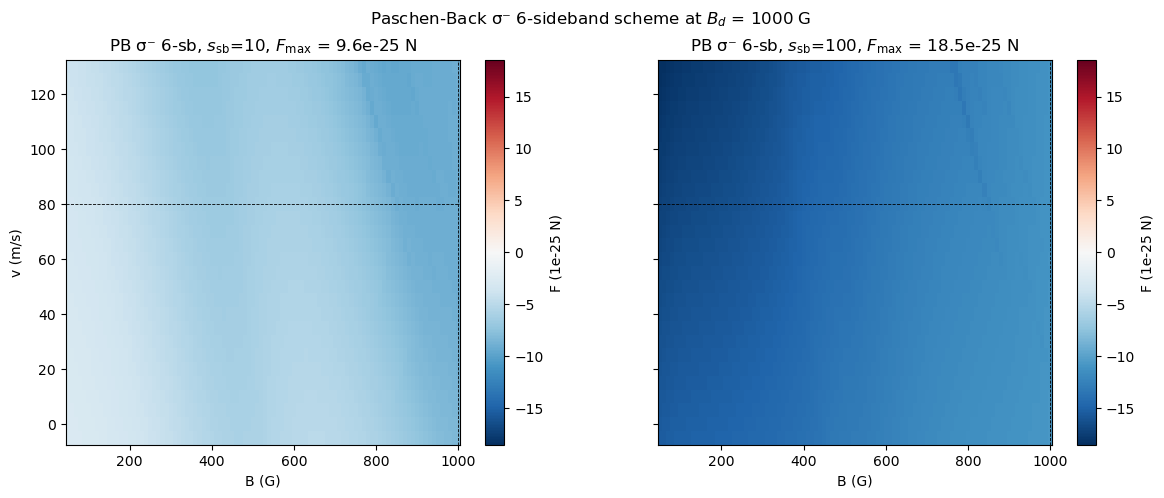

In [30]:
# F(v, B) precompute for the PB σ⁻ scheme at B_d=1000 G, both s_per_sb values.
F_surfaces_pb = {}
F_interps_pb  = {}
ref_pb        = {}   # (s_per_sb) -> (je_ref, ig_ref)  for trajectory-cell convenience
t0 = time.time()
for s_per_sb in s_values:
    sb_template, je_r, ig_r, _ = build_paschen_back_sigma_minus(g, TM, Bd_pb,
                                                                  s_per_sb=s_per_sb)
    Fg = precompute_F_grid_with_sidebands(TM, Bd_pb, v_design, sb_template,
                                            je_r, ig_r, v_grid, B_grid)
    F_surfaces_pb[s_per_sb] = Fg
    F_interps_pb[s_per_sb]  = RegularGridInterpolator(
        (v_grid, B_grid), Fg, method="linear", bounds_error=False, fill_value=0.0)
    ref_pb[s_per_sb] = (je_r, ig_r)
    iloc = np.unravel_index(np.argmax(np.abs(Fg)), Fg.shape)
    print(f"  PB σ⁻, B_d={Bd_pb:.0f} G, s_sb={s_per_sb:5.1f}: F_max = {np.abs(Fg).max()*1e25:7.2f}e-25 N "
          f"at (v={v_grid[iloc[0]]:6.1f} m/s, B={B_grid[iloc[1]]:5.0f} G)")
print(f"PB F-grid precompute: {time.time()-t0:.1f} s")

# Side-by-side heatmaps
fig, axes = plt.subplots(1, len(s_values), figsize=(7*len(s_values), 5), sharey=True)
if len(s_values) == 1: axes = [axes]
F_max_global = max(np.abs(F_surfaces_pb[s]).max() for s in s_values)
for i, s_per_sb in enumerate(s_values):
    Fg = F_surfaces_pb[s_per_sb]
    im = axes[i].pcolormesh(B_grid, v_grid, Fg*1e25,
                              shading="auto", cmap="RdBu_r",
                              vmin=-F_max_global*1e25, vmax=+F_max_global*1e25)
    axes[i].set_title(f"PB σ⁻ 6-sb, $s_{{\\rm sb}}$={s_per_sb:.0f}, $F_{{\\max}}$ = {np.abs(Fg).max()*1e25:.1f}e-25 N")
    axes[i].set_xlabel("B (G)")
    if i == 0: axes[i].set_ylabel("v (m/s)")
    axes[i].axvline(Bd_pb, color="k", lw=0.6, ls="--")
    axes[i].axhline(v_design, color="k", lw=0.6, ls="--")
    fig.colorbar(im, ax=axes[i], label="F (1e-25 N)")
fig.suptitle(f"Paschen-Back σ⁻ 6-sideband scheme at $B_d$ = {Bd_pb:.0f} G")
plt.show()


PB trajectory sweep: 136 trajectories in 9.0 s

Capture-velocity RANGE (m/s), PB σ⁻ 6-sb at B_d = 1000 G (default remix):
                         L=1.25m   L=1.75m   L=2.25m   L=2.75m
  B_d=1000 G, s_sb= 10.0:         --        --        --        --
  B_d=1000 G, s_sb=100.0:         --        --        --        --

Total PB captures: 0/136


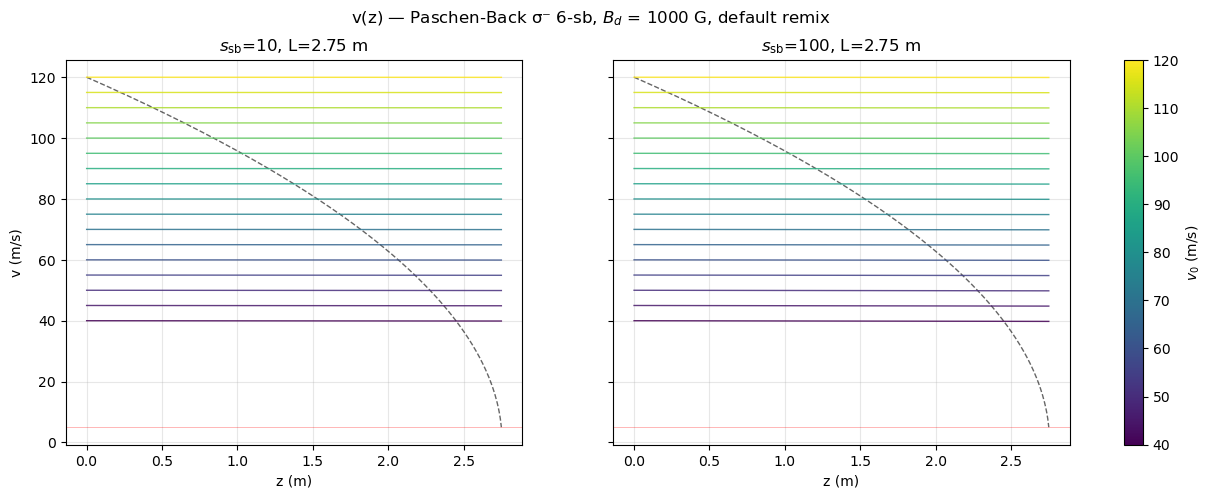

In [31]:
# Trajectory sweep: PB σ⁻ at B_d=1000 G, default remix (no dark-state mixing assumed).
results_pb = {}
t0 = time.time()
for s_per_sb in s_values:
    je_r, ig_r = ref_pb[s_per_sb]
    for L in L_values:
        z_p, v_t_p, B_p, eta = make_B_of_z_nonlinear(
            TM, je_r, ig_r, Bd_pb, v_design, v_i_sweep, v_f_sweep, L, a_max_est)
        B_of_z = interp1d(z_p, B_p, bounds_error=False,
                            fill_value=(float(B_p[0]), float(B_p[-1])))
        for v0 in v0_scan:
            sol = simulate_trajectory(v0, B_of_z, F_interps_pb[s_per_sb],
                                        mass_RaF, L,
                                        B_grid_lo=float(B_grid[0]),
                                        B_grid_hi=float(B_grid[-1]))
            results_pb[(s_per_sb, L, v0)] = dict(sol, v_target=v_t_p, z_target=z_p, eta=eta)
print(f"PB trajectory sweep: {len(results_pb)} trajectories in {time.time()-t0:.1f} s")

# Capture range table
print("\nCapture-velocity RANGE (m/s), PB σ⁻ 6-sb at B_d = 1000 G (default remix):")
print(f"{'':>22s}" + "".join(f"   L={L:.2f}m" for L in L_values))
total_pb_caps = 0
for s_per_sb in s_values:
    cells = []
    for L in L_values:
        captured = sorted([v0 for v0 in v0_scan
                             if results_pb[(s_per_sb, L, v0)]["exit_reason"] == "v_stop"])
        total_pb_caps += len(captured)
        if len(captured) == 0:
            cells.append("        --")
        elif len(captured) == 1:
            cells.append(f"     {captured[0]:3.0f}    ")
        else:
            cells.append(f"  {captured[0]:3.0f}..{captured[-1]:3.0f}  ")
    print(f"  B_d={Bd_pb:.0f} G, s_sb={s_per_sb:5.1f}: " + "".join(cells))
print(f"\nTotal PB captures: {total_pb_caps}/{len(s_values)*len(L_values)*len(v0_scan)}")

# v(z) trajectories at L = max(L_values)
L_show = max(L_values)
fig, axes = plt.subplots(1, len(s_values), figsize=(7*len(s_values), 5), sharey=True)
if len(s_values) == 1: axes = [axes]
for i, s_per_sb in enumerate(s_values):
    ax = axes[i]
    v_t = results_pb[(s_per_sb, L_show, v0_scan[0])]["v_target"]
    z_t = results_pb[(s_per_sb, L_show, v0_scan[0])]["z_target"]
    ax.plot(z_t, v_t, "k--", lw=1.0, alpha=0.6, label=r"$v_{\rm target}(z)$")
    for v0 in v0_scan:
        r = results_pb[(s_per_sb, L_show, v0)]
        ax.plot(r["z"], r["v"], "-", color=v0_cmap(v0_norm(v0)), lw=1.0, alpha=0.85)
    ax.axhline(5, color="r", lw=0.5, alpha=0.4)
    ax.set_title(f"$s_{{\\rm sb}}$={s_per_sb:.0f}, L={L_show} m")
    ax.set_xlabel("z (m)")
    if i == 0: ax.set_ylabel("v (m/s)")
    ax.grid(alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=v0_cmap, norm=v0_norm)
fig.colorbar(sm, ax=axes, label=r"$v_0$ (m/s)", fraction=0.025)
fig.suptitle(f"v(z) — Paschen-Back σ⁻ 6-sb, $B_d$ = {Bd_pb:.0f} G, default remix")
plt.show()


## Notes & next steps

**Sanity checks built in.**
- `compute_transitions_vs_B`-style normalization to max coupling at lowest sampled B (~ case-(b) stretched ME; approximate since A^2Pi_{1/2} is case-(a)/aBJ).
- BR closure (`leakage = 1 − Σ BR_subspace`) is the cross-check the existing `RaF_Zeeman_Slower.ipynb` validated.
- Rate-eq solution: `Σ N = 1` enforced and printed.

**Knobs to sweep next**
- Multi-frequency lasers (sidebands at fixed offsets).
- Multiple beam polarizations (e.g. σ⁺ + σ⁻ remixing for dark-state lifting).
- Replacing the linearized `B(z)` with cubic spline + root-find on `ν_ij(B)`.
- Toggling between `parity_e='+'` and `parity_e='-'` Λ-doublet components.

**Verification** — root CLAUDE.md gate (`jupyter execute RaF_Calcs_Tutorial.ipynb`) only applies to `Source Code/` changes; this is a notebook-only addition. To verify *this* notebook, restart kernel and Run All. Plots are gated to render only after the data step they depend on.
